## Shuffled vs. I.I.D. Draws from Discrete Distributions

When simulating heterogeneous-agent models, income shocks are drawn from a discrete approximation to the true shock distribution.  The standard approach draws each agent's shock independently (i.i.d.), so the empirical frequency of each outcome in a finite sample deviates from the target probabilities by sampling noise of order $O(1/\sqrt{N})$.

HARK's `DiscreteDistribution.draw(replicates=k)` offers an alternative: **shuffled draws** that match the target probabilities exactly by allocating $k$ copies of the minimal full-coverage sample, then randomly permuting the assignment across agents.  This eliminates sampling noise from the cross-sectional distribution of shocks in any single period.

This notebook demonstrates the difference and measures the gain.

**Related:**
- [PR #1691](https://github.com/econ-ark/HARK/pull/1691) — merged the `shuffle` parameter into HARK
- [PR #1244](https://github.com/econ-ark/HARK/pull/1244) — original (unmerged) reshuffling proposal
- [Harmenberg (2021)](https://doi.org/10.1016/j.jedc.2021.104185) — permanent-income-neutral measure (a complementary variance-reduction technique)

`# Set up the computational environment: (in JupyterLab, click the dots)`

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from HARK.distributions import DiscreteDistribution

# The key constraint: perfect $N$

Shuffle should only be used when the population size $N$ is an **exact multiple** of the minimum sample size.  For an equiprobable distribution with $J$ outcomes, that minimum is $J$ itself, so $N$ must be a multiple of $J$.  (More generally, if outcomes have probabilities $p_j = n_j / D$ in lowest terms, the minimum is $\text{lcm}$ of the denominators.)

At perfect $N$, shuffle assigns **exactly** $N/J$ agents to each outcome — zero leftover slots, zero sampling noise in the marginal frequencies.  This is a hard guarantee, not an approximation.

### Why this works: expectations are cross-sectional averages

As discussed in [Carroll (2024), *Solving Microeconomic Dynamic Stochastic Optimization Problems*](https://llorracc.github.io/SolvingMicroDSOPs) (Sections 6.2 and 10), the formula for computing an expectation over an equiprobable discrete approximation,

$$\mathbb{E}[g(\theta)] \approx \frac{1}{J}\sum_{j=1}^{J} g(\theta_j),$$

is **structurally identical** to the cross-sectional average of $J$ simulated agents each assigned one of the $J$ shock values.  When we simulate $N = k \cdot J$ agents using the shuffled draw — which assigns exactly $k$ agents to each $\theta_j$ — the cross-sectional average reproduces the expectation formula exactly:

$$\frac{1}{N}\sum_{i=1}^{N} g(\theta_i) = \frac{1}{J}\sum_{j=1}^{J} g(\theta_j).$$

This is why the shuffled-draw simulation has no sampling noise in the cross-sectional mean of any function of the shocks: the simulation **is** the expectation formula, replicated $k$ times.  

One useful implication of this point is that the use of this method of simulation eliminates a common category of bug, in which there is some subtle but numerically significant difference between the expectations calculated using the solution algorithm and the results of the simulation.  Such a bug is impossible when the formulae for expectations and simulation are identical.

### The `replicates` parameter

The `replicates` parameter handles the bookkeeping: `F.draw(replicates=k)` computes the minimal full-coverage size automatically, multiplies by $k$, and forces shuffled draws.  It warns if `1/p_j` is not an integer for some outcome.

To see the difference concretely, we draw $k = 5$ replicates (giving $N = 5 \times 4 = 20$) from a $J = 4$ equiprobable distribution using both methods.

# Minimum sample size $J_{\min}$ for general distributions

For an equiprobable distribution with $J$ outcomes, the minimum sample size is simply $J$.  For a general probability vector $(p_1, \ldots, p_J)$, we need the smallest positive integer $N$ such that $N \cdot p_j$ is a positive integer for every atom $j$.

**Computation.**  Express each $p_j$ as a fraction $n_j / d_j$ in lowest terms.  Then

$$J_{\min} = \operatorname{lcm}(d_1, \ldots, d_J).$$

### Product-of-conditional-inverses interpretation

When a distribution is a joint over independent shock dimensions, $J_{\min}$ factors as the **product** of the inverse conditional probabilities at each level of the hierarchy.

*Example:* Suppose the unemployment probability is $p_u = 0.05 = 1/20$, and conditional on employment there are $3$ equiprobable permanent shocks and $3$ equiprobable transitory shocks.  The joint distribution has $1 + 3 \times 3 = 10$ atoms:

| Atom | Probability | As fraction |
|------|------------|-------------|
| Unemployed | $0.05$ | $1/20$ |
| Each of 9 employed states | $0.95/9$ | $19/180$ |

The denominators are $20$ and $180$, so $J_{\min} = \operatorname{lcm}(20, 180) = 180$.  This equals the product of conditional inverses:

$$J_{\min} = \underbrace{20}_{1/p_u} \times \underbrace{3}_{1/p_{\text{perm}|\text{emp}}} \times \underbrace{3}_{1/p_{\text{tran}|\text{emp}}} = 180.$$

With $N = 180$: exactly $9$ unemployed agents, $171$ employed agents, and each of the $9$ (perm, tran) combinations is assigned to exactly $171/9 = 19$ employed agents.

### Validation criterion

For shuffled draws to be practical, $J_{\min}$ must not be too large.  A large $J_{\min}$ means at least one shock dimension has a very fine conditional probability, requiring an impractically large population even for $k = 1$ replicate.

**Rule:** if $J_{\min} > 10{,}000$, the `replicates` parameter raises an error.  This corresponds roughly to saying that no conditional shock probability should be smaller than $0.01\%$ (i.e., no conditional inverse exceeds $10{,}000$).  In practice, standard HARK shock approximations (typically 3–11 equiprobable points) produce $J_{\min}$ well under this bound.

If $J_{\min}$ is unexpectedly large, this usually signals that the distribution was not constructed from clean rational probabilities — for instance, if the shock approximation used quadrature weights that are irrational.  The remedy is to use equiprobable discretizations, which always give $J_{\min} = J$.

# Individual-agent equivalence of shuffled and i.i.d. draws

Before showing simulation evidence, it is worth establishing a basic fact: **from the standpoint of any single agent, the shuffle procedure is indistinguishable from i.i.d. sampling.**  The variance reduction is *entirely* a property of the joint distribution across agents; no individual's marginal law is altered.

**Setup.** A discrete distribution with $J$ atoms: value $x_j$ with probability $p_j$, $\sum_j p_j = 1$.  We have $N$ agents indexed $i = 1,\dots,N$.  Let $X_i$ be the value assigned to agent $i$.

**I.i.d. baseline.** Each agent independently draws
$$\Pr(X_i = x_j) = p_j, \qquad \mathbb{E}[X_i] = \sum_j p_j x_j \equiv \mu.$$

**Shuffle procedure.** Two stages:

1. *Count stage.* Produce a (possibly random) count vector $K = (K_1,\dots,K_J)$ with $\sum_j K_j = N$, satisfying the unbiasedness property
$$\mathbb{E}[K_j] = N p_j \quad \text{for every } j. \tag{$\star$}$$
The floor-plus-leftover algorithm achieves $(\star)$: it sets $K_j = \lfloor N p_j\rfloor + L_j$, where the $M = N - \sum_j \lfloor N p_j\rfloor$ leftover slots are distributed so that $\mathbb{E}[L_j] = N p_j - \lfloor N p_j\rfloor$.  When $N p_j \in \mathbb{Z}$ for every $j$ (i.e. $N$ is a multiple of $J_{\min}$), the leftover stage is empty and $K_j = N p_j$ deterministically.

2. *Assignment stage.* Conditional on $K$, draw a uniformly random permutation $\pi$ of $\{1,\dots,N\}$ and assign the first $K_1$ permuted indices to atom $1$, the next $K_2$ to atom $2$, and so on.

**Claim.** For every agent $i$ and every atom $j$,
$$\Pr(X_i = x_j) = p_j.$$

**Proof.** Condition on $K$.  By the symmetry (exchangeability) of a uniformly random permutation, agent $i$ is equally likely to occupy any of the $N$ slots, so
$$\Pr(X_i = x_j \mid K) = \frac{K_j}{N}.$$
Taking expectation over $K$ and using $(\star)$,
$$\Pr(X_i = x_j) = \mathbb{E}\!\left[\frac{K_j}{N}\right] = \frac{\mathbb{E}[K_j]}{N} = \frac{N p_j}{N} = p_j. \qquad\blacksquare$$

**Consequences for agent $i$.**

- *Expected value:* $\mathbb{E}[X_i] = \sum_j p_j x_j = \mu$, identical to i.i.d.
- *Any moment / any function:* $\mathbb{E}[f(X_i)] = \sum_j p_j f(x_j)$ for arbitrary $f$, since the marginal law of $X_i$ is unchanged.
- *Entire marginal distribution:* $X_i$ has exactly the same law under shuffle as under i.i.d.  From the agent's own perspective, the two procedures are indistinguishable.

**What does change.** Only the *joint* distribution across agents differs.  Under i.i.d., the $X_i$ are independent, so $\operatorname{Var}\!\left(\tfrac{1}{N}\sum_i X_i\right) = \sigma^2/N$ where $\sigma^2 = \sum_j p_j(x_j-\mu)^2$.  Under shuffle, the assignments are negatively correlated — one agent receiving atom $j$ slightly reduces another's chance — and the empirical count $K_j/N$ has variance smaller than $p_j(1-p_j)/N$, exactly zero whenever $N p_j$ is an integer.  The reduction in cross-sectional sampling noise is therefore *entirely* a property of the joint law; the marginal law each agent faces is preserved exactly.

In short: **shuffling redistributes correlation across agents without altering any single agent's probability law.**  No agent can detect the difference by examining their own outcomes — only an outside observer aggregating across the population sees the variance reduction.

> ⚠ **Caveat for paired-scenario estimators.** The marginal-law equivalence
> proved above holds *within a single simulation*. It does **not** imply
> that two simulations using identical per-agent random draws — one with
> `shuffle=True` and one with `shuffle=False` — produce identical
> per-agent target assignments. Under the default shuffle, agent $i$'s
> target depends only on their position in a random permutation, not on
> their per-agent draw $u_i$. So if you compare a shuffled run to an
> iid run agent-by-agent (e.g., to validate the shuffle, or to use one
> as a pre-conditioner for the other), you will find that a substantial
> fraction of agents are at *different* target states despite seeing the
> same draws.
>
> For estimators that integrate over per-agent trajectories using
> common random numbers across counterfactual scenarios — for example
> CRN-coupled welfare integrals
> $\frac{1}{N}\sum_i [u(c^{\rm pol}_i) - u(c^{\rm base}_i)] / u'(c^{\rm anchor}_i)$ —
> per-agent identity preservation across methods *does* matter at finite
> $N$. The new `draws=` argument introduced in the section below
> addresses this case: it preserves quota-exact counts AND ensures each
> agent's target is determined by their per-agent draw, so the shuffled
> simulation is per-agent-equivalent to iid as $N \to \infty$ via
> Glivenko–Cantelli.


In [2]:
# Equiprobable J=4 distribution (same one used throughout the notebook)
J_demo = 4
P_demo = np.ones(J_demo) / J_demo
log_psi_spread_demo = 0.1
log_vals_demo = np.linspace(-log_psi_spread_demo, log_psi_spread_demo, J_demo)
X_demo = np.exp(log_vals_demo)
X_demo = X_demo / np.mean(X_demo)  # E[psi] = 1
F_demo = DiscreteDistribution(P_demo, X_demo, seed=0)

k_demo = 5  # replicates
N_demo = k_demo * J_demo  # = 20

print(f"J = {J_demo} equiprobable outcomes")
print(f"Outcomes (psi values): {X_demo.round(6)}")
print(f"replicates = {k_demo}  →  N = {k_demo} × {J_demo} = {N_demo}")


def empirical_freq(draws, atoms):
    """Compute empirical frequency of each atom in the draws."""
    freq = np.array([np.sum(np.isclose(draws, a)) for a in atoms])
    return freq / len(draws)

J = 4 equiprobable outcomes
Outcomes (psi values): [0.902329 0.964535 1.031029 1.102107]
replicates = 5  →  N = 5 × 4 = 20


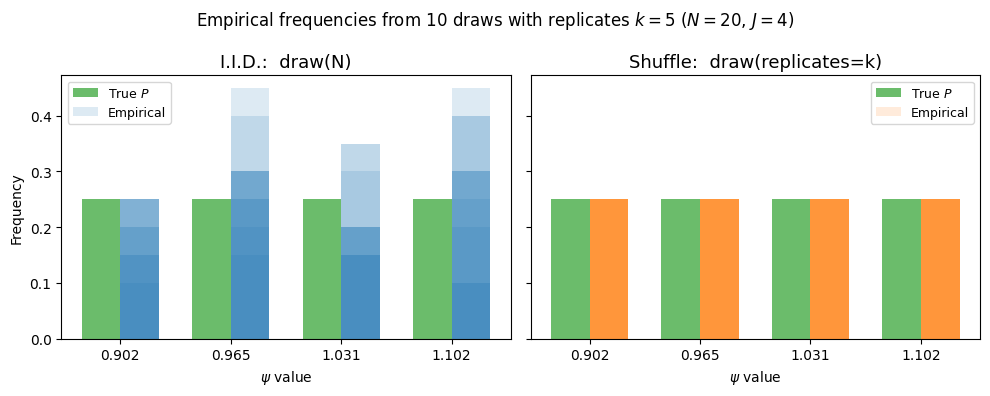

With draw(replicates=k), every repetition gives exactly 1/J per outcome.


In [3]:
# Compare i.i.d. draw(N) vs shuffled draw(replicates=k), 10 repetitions
n_reps = 10
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bar_width = 0.35
x_pos = np.arange(J_demo)

for ax, use_replicates, title in [
    (axes[0], False, "I.I.D.:  draw(N)"),
    (axes[1], True, "Shuffle:  draw(replicates=k)"),
]:
    ax.bar(
        x_pos - bar_width / 2,
        P_demo,
        bar_width,
        label="True $P$",
        alpha=0.7,
        color="C2",
    )
    for r in range(n_reps):
        F_r = DiscreteDistribution(P_demo, X_demo, seed=r)
        if use_replicates:
            draws = F_r.draw(replicates=k_demo)
        else:
            draws = F_r.draw(N_demo)
        freq = empirical_freq(draws, X_demo)
        ax.bar(
            x_pos + bar_width / 2,
            freq,
            bar_width,
            alpha=0.15,
            color="C0" if not use_replicates else "C1",
            label="Empirical" if r == 0 else None,
        )
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{v:.3f}" for v in X_demo])
    ax.set_xlabel(r"$\psi$ value")
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Frequency")
fig.suptitle(
    f"Empirical frequencies from {n_reps} draws with replicates $k = {k_demo}$ ($N = {N_demo}$, $J = {J_demo}$)",
    fontsize=12,
)
fig.tight_layout()
plt.show()
print("With draw(replicates=k), every repetition gives exactly 1/J per outcome.")

# Time-series variance of the cross-sectional mean

In a simulation with $N$ agents, the cross-sectional mean of $\mathbf{p}$ (or $\log\mathbf{p}$) fluctuates from period to period.  The **time-series variance** of this mean quantifies how noisy the simulation's aggregate dynamics are.

After an initial transient, $\bar{\ell}_n = \frac{1}{N}\sum_i \log\mathbf{p}_{i,n}$ follows an approximate AR(1):

$$\bar{\ell}_{n+1} \approx (1-d)\,\bar{\ell}_n + \mu + \eta_n$$

where $\eta_n$ has two independent components:
- **Death noise:** agents who die (and get replaced at $\log\mathbf{p} = 0$) perturb the mean.  Variance $\approx \frac{d(1-d)}{N}\bigl(V_\infty + E_\infty^2\bigr)$, where $V_\infty, E_\infty$ are the ergodic cross-sectional variance and mean of $\log\mathbf{p}$.
- **Shock noise:** the empirical mean of $\log\psi$ deviates from $\mu$.  With i.i.d. draws, variance $= \sigma^2/N$.  With **shuffle at perfect $N$**, this is **exactly zero**.

### Analytical formula

The ergodic time-series variance of an AR(1) with coefficient $\rho = 1-d$ and innovation variance $v$ is $v/(1-\rho^2)$.  So:

$$\text{Var}_{\text{ts}}^{\text{shf}} = \frac{(1-d)(V_\infty + E_\infty^2)}{N(2-d)}, \qquad
\text{Var}_{\text{ts}}^{\text{iid}} = \text{Var}_{\text{ts}}^{\text{shf}} + \frac{\sigma^2}{N\,d(2-d)}$$

Both scale as $1/N$, so the **variance-reduction ratio is constant** in $N$:

$$R = \frac{\text{Var}_{\text{ts}}^{\text{iid}}}{\text{Var}_{\text{ts}}^{\text{shf}}} = 1 + \frac{\sigma^2}{d(1-d)(V_\infty + E_\infty^2)}$$

In [4]:
# --- Parameters ---
J = 4  # equiprobable permanent shock outcomes
death_prob = 0.02
T = 400  # total periods
burn = 100  # discard first 100 periods

# Sweep over replicates: N = k * J
replicates = [4, 16, 64]

# Equiprobable permanent shock distribution, E[psi] = 1
log_psi_spread = 0.1
log_psi_vals = np.linspace(-log_psi_spread, log_psi_spread, J)
psi_vals = np.exp(log_psi_vals)
psi_vals = psi_vals / np.mean(psi_vals)
P_equi = np.ones(J) / J

mu = np.mean(np.log(psi_vals))
sigma2 = np.var(np.log(psi_vals))
d = death_prob

# Ergodic cross-sectional moments
V_erg = (1 - d) / d * sigma2 + (1 - d) / d**2 * mu**2  # Var(log p)
E_erg = (1 - d) * mu / d  # E[log p]


# Theoretical time-series variances (functions of N)
def theory_ts_var_shf(N):
    return (1 - d) * (V_erg + E_erg**2) / (N * (2 - d))


def theory_ts_var_iid(N):
    return theory_ts_var_shf(N) + sigma2 / (N * d * (2 - d))


R_theory = 1 + sigma2 / (d * (1 - d) * (V_erg + E_erg**2))

print(f"J = {J},  d = {death_prob},  T = {T},  burn-in = {burn}")
print(f"mu = {mu:.6f},  sigma^2 = {sigma2:.6f}")
print(f"Ergodic V_inf = {V_erg:.6f},  E_inf = {E_erg:.6f}")
print(f"V_inf + E_inf^2 = {V_erg + E_erg**2:.6f}")
print(f"\nTheoretical variance-reduction ratio R = {R_theory:.3f}")
print(f"Replicates k: {replicates}  →  N: {[k * J for k in replicates]}")

J = 4,  d = 0.02,  T = 400,  burn-in = 100
mu = -0.002776,  sigma^2 = 0.005556
Ergodic V_inf = 0.291103,  E_inf = -0.136026
V_inf + E_inf^2 = 0.309606

Theoretical variance-reduction ratio R = 1.916
Replicates k: [4, 16, 64]  →  N: [16, 64, 256]


`# Run simulations for each N, compute time-series variance of mean(pLvl) and mean(log pLvl):`

In [5]:
import time


def simulate_one(k, J, T, psi_vals, P_equi, death_prob, seed, shuffle):
    """Run one simulation, return time series of mean(pLvl) and mean(log pLvl).

    k : int — number of replicates (N = k * J)
    """
    N = k * J
    rng = np.random.default_rng(seed)
    F = DiscreteDistribution(P_equi, psi_vals, seed=seed + 1000)

    log_pLvl = np.zeros(N)
    mean_log = np.zeros(T)
    mean_lvl = np.zeros(T)

    for t in range(T):
        dies = rng.random(N) < death_prob
        log_pLvl[dies] = 0.0
        if shuffle:
            psi_draws = F.draw(replicates=k)
        else:
            psi_draws = F.draw(N)
        log_pLvl += np.log(psi_draws)
        mean_log[t] = np.mean(log_pLvl)
        mean_lvl[t] = np.mean(np.exp(log_pLvl))

    return mean_log, mean_lvl


# Use a small number of seeds and track variation across seeds for error bands
n_seeds = 15

# Per-seed time-series variances (so we can compute mean and std across seeds)
ts_var_log_iid_seeds = np.zeros((len(replicates), n_seeds))
ts_var_log_shf_seeds = np.zeros((len(replicates), n_seeds))
ts_var_lvl_iid_seeds = np.zeros((len(replicates), n_seeds))
ts_var_lvl_shf_seeds = np.zeros((len(replicates), n_seeds))
time_iid = np.zeros(len(replicates))
time_shf = np.zeros(len(replicates))

for ri, k in enumerate(replicates):
    N = k * J

    t0 = time.perf_counter()
    for s in range(n_seeds):
        ml_i, mp_i = simulate_one(
            k, J, T, psi_vals, P_equi, death_prob, seed=s, shuffle=False
        )
        ts_var_log_iid_seeds[ri, s] = np.var(ml_i[burn:])
        ts_var_lvl_iid_seeds[ri, s] = np.var(mp_i[burn:])
    time_iid[ri] = time.perf_counter() - t0

    t0 = time.perf_counter()
    for s in range(n_seeds):
        ml_s, mp_s = simulate_one(
            k, J, T, psi_vals, P_equi, death_prob, seed=s + 500, shuffle=True
        )
        ts_var_log_shf_seeds[ri, s] = np.var(ml_s[burn:])
        ts_var_lvl_shf_seeds[ri, s] = np.var(mp_s[burn:])
    time_shf[ri] = time.perf_counter() - t0

# Means across seeds (for plotting)
ts_var_log_iid = ts_var_log_iid_seeds.mean(axis=1)
ts_var_log_shf = ts_var_log_shf_seeds.mean(axis=1)
ts_var_lvl_iid = ts_var_lvl_iid_seeds.mean(axis=1)
ts_var_lvl_shf = ts_var_lvl_shf_seeds.mean(axis=1)

# Std-across-seeds for crude 1-std error bands on the IID figures
ts_var_log_iid_std = ts_var_log_iid_seeds.std(axis=1, ddof=1)
ts_var_lvl_iid_std = ts_var_lvl_iid_seeds.std(axis=1, ddof=1)
ts_var_log_shf_std = ts_var_log_shf_seeds.std(axis=1, ddof=1)
ts_var_lvl_shf_std = ts_var_lvl_shf_seeds.std(axis=1, ddof=1)

for ri, k in enumerate(replicates):
    N = k * J
    ratio_log = (
        ts_var_log_iid[ri] / ts_var_log_shf[ri]
        if ts_var_log_shf[ri] > 0
        else float("inf")
    )
    ratio_lvl = (
        ts_var_lvl_iid[ri] / ts_var_lvl_shf[ri]
        if ts_var_lvl_shf[ri] > 0
        else float("inf")
    )
    time_ratio = time_shf[ri] / time_iid[ri] if time_iid[ri] > 0 else float("inf")
    print(
        f"k={int(k):>3d}  N={N:>4d}  "
        f"log: iid={ts_var_log_iid[ri]:.2e}±{ts_var_log_iid_std[ri]:.1e} "
        f"shf={ts_var_log_shf[ri]:.2e} ratio={ratio_log:.2f}x  |  "
        f"lvl: iid={ts_var_lvl_iid[ri]:.2e}±{ts_var_lvl_iid_std[ri]:.1e} "
        f"shf={ts_var_lvl_shf[ri]:.2e} ratio={ratio_lvl:.2f}x  |  "
        f"time: iid={time_iid[ri]:.2f}s shf={time_shf[ri]:.2f}s ({time_ratio:.2f}x)"
    )

k=  4  N=  16  log: iid=1.25e-02±7.1e-03 shf=8.18e-03 ratio=1.53x  |  lvl: iid=1.72e-02±8.8e-03 shf=1.43e-02 ratio=1.20x  |  time: iid=0.07s shf=0.27s (3.96x)
k= 16  N=  64  log: iid=3.21e-03±1.9e-03 shf=1.54e-03 ratio=2.08x  |  lvl: iid=4.19e-03±1.8e-03 shf=1.90e-03 ratio=2.21x  |  time: iid=0.08s shf=0.27s (3.64x)
k= 64  N= 256  log: iid=9.51e-04±5.2e-04 shf=5.21e-04 ratio=1.83x  |  lvl: iid=1.14e-03±6.3e-04 shf=1.01e-03 ratio=1.13x  |  time: iid=0.10s shf=0.33s (3.16x)


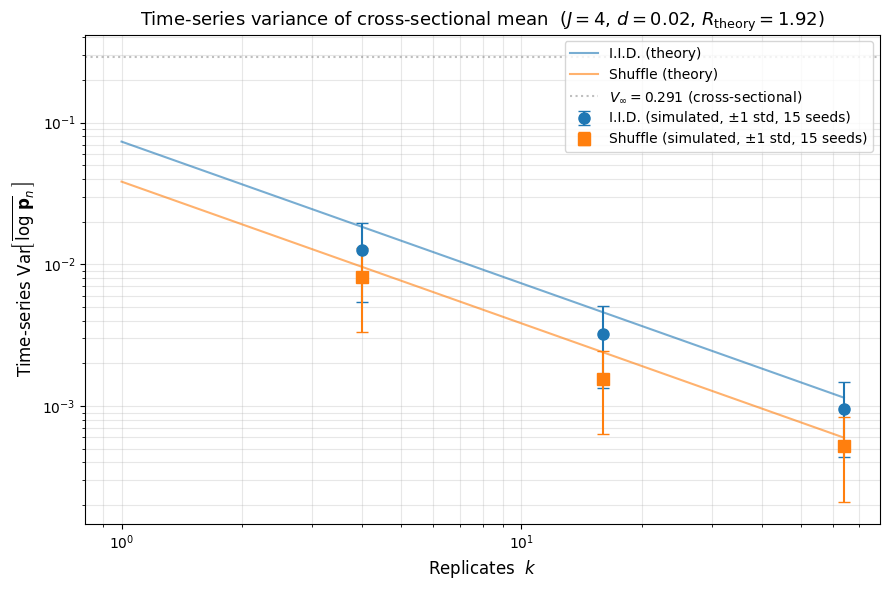

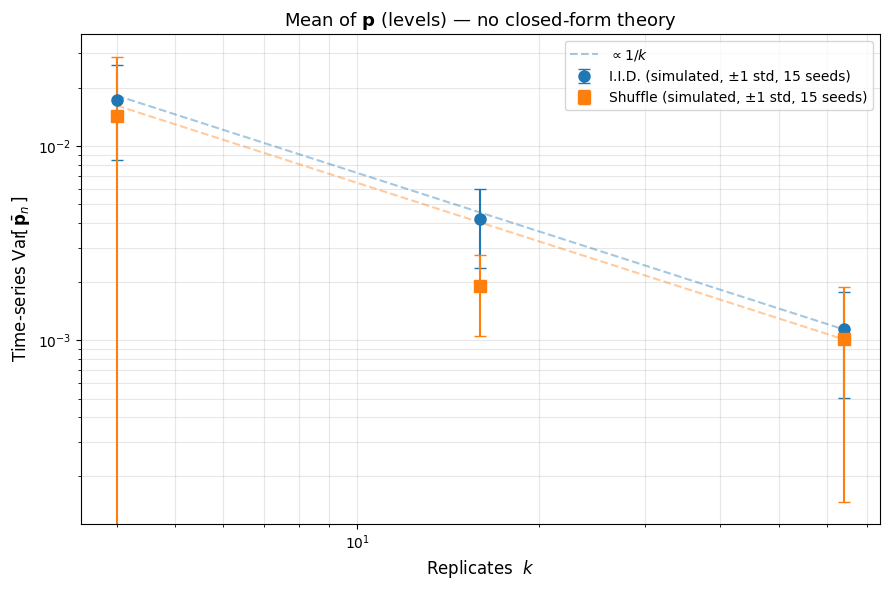

In [6]:
# --- Main figure: time-series variance of mean(log pLvl) vs replicates ---
# with theoretical predictions overlaid and 1-std error bands from seeds

reps = np.array(replicates)
k_fine = np.logspace(0, np.log10(reps[-1]), 200)
N_fine = k_fine * J

fig, ax = plt.subplots(figsize=(9, 6))

# Simulated points with 1-std error bars across seeds
ax.errorbar(
    reps,
    ts_var_log_iid,
    yerr=ts_var_log_iid_std,
    fmt="o",
    color="C0",
    markersize=8,
    capsize=4,
    zorder=5,
    label=f"I.I.D. (simulated, ±1 std, {n_seeds} seeds)",
)
ax.errorbar(
    reps,
    ts_var_log_shf,
    yerr=ts_var_log_shf_std,
    fmt="s",
    color="C1",
    markersize=8,
    capsize=4,
    zorder=5,
    label=f"Shuffle (simulated, ±1 std, {n_seeds} seeds)",
)

# Theory
ax.loglog(
    k_fine,
    theory_ts_var_iid(N_fine),
    "-",
    color="C0",
    alpha=0.6,
    label="I.I.D. (theory)",
)
ax.loglog(
    k_fine,
    theory_ts_var_shf(N_fine),
    "-",
    color="C1",
    alpha=0.6,
    label="Shuffle (theory)",
)

ax.set_xscale("log")
ax.set_yscale("log")

# Ergodic cross-sectional variance as reference
ax.axhline(
    V_erg,
    color="gray",
    linestyle=":",
    alpha=0.5,
    label=f"$V_\\infty = {V_erg:.3f}$ (cross-sectional)",
)

ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(
    r"Time-series Var$\!\left[\,\overline{\log\,\mathbf{p}}_n\,\right]$", fontsize=12
)
ax.set_title(
    f"Time-series variance of cross-sectional mean  "
    f"($J={J}$, $d={death_prob}$, $R_{{\\mathrm{{theory}}}}={R_theory:.2f}$)",
    fontsize=13,
)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

# --- Same for levels ---
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    reps,
    ts_var_lvl_iid,
    yerr=ts_var_lvl_iid_std,
    fmt="o",
    color="C0",
    markersize=8,
    capsize=4,
    label=f"I.I.D. (simulated, ±1 std, {n_seeds} seeds)",
)
ax.errorbar(
    reps,
    ts_var_lvl_shf,
    yerr=ts_var_lvl_shf_std,
    fmt="s",
    color="C1",
    markersize=8,
    capsize=4,
    label=f"Shuffle (simulated, ±1 std, {n_seeds} seeds)",
)
ax.set_xscale("log")
ax.set_yscale("log")
# No clean theory for levels, just 1/k reference lines anchored at the largest k
ref_iid = ts_var_lvl_iid[-1] * reps[-1] / reps
ref_shf = ts_var_lvl_shf[-1] * reps[-1] / reps
ax.loglog(reps, ref_iid, "--", color="C0", alpha=0.4, label=r"$\propto 1/k$")
ax.loglog(reps, ref_shf, "--", color="C1", alpha=0.4)
ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(r"Time-series Var$\!\left[\,\bar{\mathbf{p}}_n\,\right]$", fontsize=12)
ax.set_title(r"Mean of $\mathbf{p}$ (levels) — no closed-form theory", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

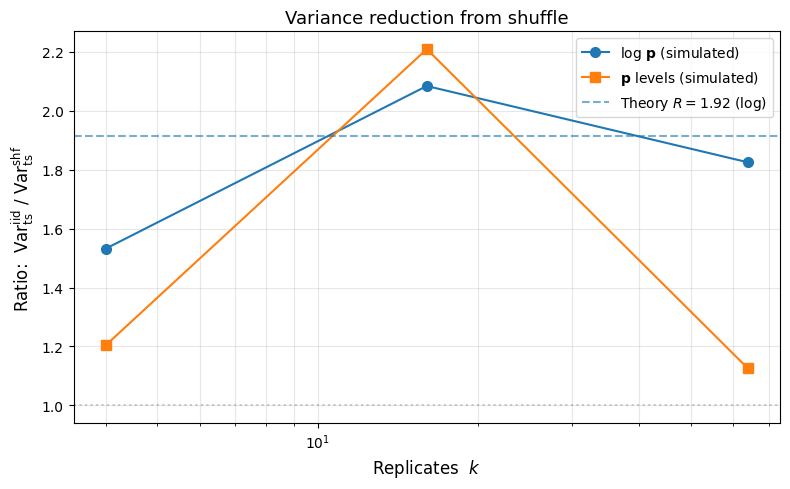

In [7]:
# --- Ratio plot with theoretical prediction ---
ratio_log = ts_var_log_iid / ts_var_log_shf
ratio_lvl = ts_var_lvl_iid / ts_var_lvl_shf

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(
    reps, ratio_log, "o-", label=r"$\log\,\mathbf{p}$ (simulated)", markersize=7
)
ax.semilogx(
    reps, ratio_lvl, "s-", label=r"$\mathbf{p}$ levels (simulated)", markersize=7
)
ax.axhline(
    R_theory,
    color="C0",
    linestyle="--",
    alpha=0.6,
    label=f"Theory $R = {R_theory:.2f}$ (log)",
)
ax.axhline(1, color="gray", linestyle=":", alpha=0.4)
ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(
    r"Ratio:  Var$_{\mathrm{ts}}^{\mathrm{iid}}$ / Var$_{\mathrm{ts}}^{\mathrm{shf}}$",
    fontsize=12,
)
ax.set_title("Variance reduction from shuffle", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

# Summary

The time-series variance of $\overline{\log\mathbf{p}}$ has two components, both scaling as $1/N$:

| Source | Variance contribution | Shuffle? |
|--------|----------------------|----------|
| Death noise | $\frac{(1-d)(V_\infty + E_\infty^2)}{N(2-d)}$ | Same |
| Shock noise | $\frac{\sigma^2}{Nd(2-d)}$ | **Eliminated** |

The variance-reduction ratio $R = 1 + \frac{\sigma^2}{d(1-d)(V_\infty + E_\infty^2)}$ is a **constant** independent of $N$.  For these parameters, $R \approx 1.9$: shuffle roughly halves the time-series variance, regardless of how many agents are simulated.

The log-log plot confirms that simulated points lie on the theoretical curves, validating the AR(1) approximation.  The $V_\infty$ reference line shows the scale of cross-sectional dispersion for context — the time-series variance of the *mean* is orders of magnitude smaller (by a factor of $\sim N$).

# Application: Markov employment model with shuffled income shocks

The simple permanent-income simulation above demonstrates the mechanics of shuffled draws.  Now we apply the same technique to a more realistic setting: a **Markov employment model** inspired by [HAFiscal](https://github.com/econ-ark/HAFiscal), stripped of aggregate shocks and fiscal experiments.

## Model overview

Agents transition between **7 discrete employment states**:

| State | Label | Income (as fraction of $\mathbf{p}$) |
|:-----:|-------|--------------------------------------|
| 0 | Employed | Lognormal permanent ($\psi$) and transitory ($\theta$) shocks |
| 1 | Unemployed, UI quarter 1 | Deterministic: $\psi=1$, $\theta=0.7$ |
| 2 | Unemployed, UI quarter 2 | Deterministic: $\psi=1$, $\theta=0.7$ |
| 3 | Unemployed, no benefits, quarter 3 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 4 | Unemployed, no benefits, quarter 4 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 5 | Unemployed, no benefits, quarter 5 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 6 | Unemployed, no benefits, quarter 6 | Deterministic: $\psi=1$, $\theta=0.5$ → **forced reemployment** |

Unemployment spells are capped at 6 quarters: state 6 transitions to employment with probability 1.  This ensures a finite state space with rational steady-state probabilities, so `income_shuffle` can achieve exact frequency matching within each state.

### Transition matrix

Parameterized by:
- Steady-state unemployment rate $u = 0.05$ (quarterly)
- Average unemployment duration $\bar{U} = 1.5$ quarters
- UI benefit duration: 2 quarters (states 1–2)

The reemployment probability from any unemployed state is $1 - U_{\text{persist}} = 1/\bar{U} \approx 0.667$, except state 6 which forces reemployment.

### Key question

With `income_shuffle=True`, the employed agents' income shocks ($\psi, \theta$) are drawn with exact frequency matching.  The Markov transitions themselves remain stochastic.  Does eliminating the shock-noise component measurably reduce the time-series variance of aggregate consumption?

In [8]:
from HARK.ConsumptionSaving.ConsMarkovModel import MarkovConsumerType
from HARK.distributions import (
    DiscreteDistribution,
    DiscreteDistributionLabeled,
    combine_indep_dstns,
    MeanOneLogNormal,
)
from fractions import Fraction
from math import lcm
from functools import reduce

# --- Calibration: clean fractions for exact shuffle replication ---
#
# For shuffled draws to be *exact* (no floor-plus-leftover residual), the
# population size N must be a multiple of J_min — the smallest integer such
# that N * p_j is an integer for every per-period outcome j.
#
# An employed agent faces three independent events each period:
#   1. Death with probability pDie
#   2. Job loss with probability p_lose (conditional on survival)
#   3. One of 49 equiprobable income shocks (conditional on survival & employment)
#
# Choosing pDie and p_lose as unit fractions (1/k) makes J_min manageable.

K = 7  # Markov states: E, U1, U2, U3, U4, U5, U6

# --- Death probability: pDie = 1/126 ---
# LivPrb ≈ 0.9921, expected lifespan = 126 quarters ≈ 31.5 years
pDie = Fraction(1, 126)
LivPrb_val = float(1 - pDie)

# --- Job-loss probability: p_lose = 1/50 ---
# With p_find ≈ 0.3518 and forced reemployment after 6 quarters,
# the 7-state chain yields a steady-state unemployment rate of 5%.
p_lose = Fraction(1, 50)
p_find = 0.351819  # solved numerically for 5% steady-state urate

# --- Compute J_min for the full per-period outcome distribution ---
J_income = 49  # 7 PermShk × 7 TranShk, equiprobable
p_die_out = pDie
p_surv_lose = (1 - pDie) * p_lose
p_surv_emp_each = (1 - pDie) * (1 - p_lose) / J_income
all_probs = [p_die_out, p_surv_lose] + [p_surv_emp_each] * J_income
assert sum(all_probs) == 1, f"Probabilities sum to {sum(all_probs)}"
J_min = reduce(lcm, [p.denominator for p in all_probs])

print(f"pDie = {pDie} = {float(pDie):.6f}  (LivPrb = {LivPrb_val:.6f})")
print(f"p_lose = {p_lose} = {float(p_lose):.4f}")
print(f"J_income = {J_income}  (7 × 7 equiprobable)")
print(f"J_min = {J_min}")
print(
    f"  Per block: {int(J_min * p_die_out)} die, "
    f"{int(J_min * p_surv_lose)} lose job, "
    f"{int(J_min * p_surv_emp_each)} × 49 = "
    f"{int(J_min * p_surv_emp_each) * 49} get income shocks "
    f"({int(J_min * p_surv_emp_each)} replicates)"
)

# --- Markov transition matrix ---
TM = np.zeros((K, K))
TM[0, 0] = 1 - float(p_lose)
TM[0, 1] = float(p_lose)  # employed → U1
for s in range(1, 6):
    TM[s, 0] = p_find  # reemployment
    TM[s, s + 1] = 1 - p_find  # advance to next unemployment quarter
TM[6, 0] = 1.0  # forced reemployment after 6 quarters

print("\nTransition matrix (rows = from, cols = to):")
state_labels = ["E", "U1", "U2", "U3", "U4", "U5", "U6"]
header = "     " + "  ".join(f"{s:>6s}" for s in state_labels)
print(header)
for i, row in enumerate(TM):
    print(f"  {state_labels[i]:>2s}  " + "  ".join(f"{v:6.4f}" for v in row))

# Verify: steady-state distribution
eigvals, eigvecs = np.linalg.eig(TM.T)
ss_idx = np.argmin(np.abs(eigvals - 1.0))
ss_dist = np.real(eigvecs[:, ss_idx])
ss_dist = ss_dist / ss_dist.sum()
print("\nSteady-state distribution:")
for s, p in zip(state_labels, ss_dist):
    print(f"  {s}: {p:.4f}")
print(f"  Total unemployment: {ss_dist[1:].sum():.4f}")

/home/shared/github/llorracc/HAFiscal-Latest/.venv/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


pDie = 1/126 = 0.007937  (LivPrb = 0.992063)
p_lose = 1/50 = 0.0200
J_income = 49  (7 × 7 equiprobable)
J_min = 252
  Per block: 2 die, 5 lose job, 5 × 49 = 245 get income shocks (5 replicates)

Transition matrix (rows = from, cols = to):
          E      U1      U2      U3      U4      U5      U6
   E  0.9800  0.0200  0.0000  0.0000  0.0000  0.0000  0.0000
  U1  0.3518  0.0000  0.6482  0.0000  0.0000  0.0000  0.0000
  U2  0.3518  0.0000  0.0000  0.6482  0.0000  0.0000  0.0000
  U3  0.3518  0.0000  0.0000  0.0000  0.6482  0.0000  0.0000
  U4  0.3518  0.0000  0.0000  0.0000  0.0000  0.6482  0.0000
  U5  0.3518  0.0000  0.0000  0.0000  0.0000  0.0000  0.6482
  U6  1.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000

Steady-state distribution:
  E: 0.9500
  U1: 0.0190
  U2: 0.0123
  U3: 0.0080
  U4: 0.0052
  U5: 0.0034
  U6: 0.0022
  Total unemployment: 0.0500


In [9]:
# --- Income shock distributions by state ---

# Employed: lognormal permanent + transitory shocks (HAFiscal calibration)
PermShkDstn_emp = MeanOneLogNormal(np.sqrt(0.003)).discretize(7, method="equiprobable")
TranShkDstn_emp = MeanOneLogNormal(np.sqrt(0.12)).discretize(7, method="equiprobable")
emp_dstn_raw = combine_indep_dstns(PermShkDstn_emp, TranShkDstn_emp)
emp_dstn = DiscreteDistributionLabeled(
    pmv=emp_dstn_raw.pmv,
    atoms=emp_dstn_raw.atoms,
    var_names=["PermShk", "TranShk"],
)

# Unemployed with UI (states 1-2): deterministic PermShk=1, TranShk=0.7
ui_dstn = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.7]]),
    var_names=["PermShk", "TranShk"],
)

# Unemployed, no benefits (states 3-6): deterministic PermShk=1, TranShk=0.5
nob_dstn = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.5]]),
    var_names=["PermShk", "TranShk"],
)

# IncShkDstn: list of lists, [period][state]
IncShkDstn_markov = [
    [emp_dstn, ui_dstn, ui_dstn, nob_dstn, nob_dstn, nob_dstn, nob_dstn]
]

# Marginal distributions for the solver
PermShkDstn_unemp = DiscreteDistribution(np.ones(1), np.array([1.0]))
TranShkDstn_ui = DiscreteDistribution(np.ones(1), np.array([0.7]))
TranShkDstn_nob = DiscreteDistribution(np.ones(1), np.array([0.5]))

PermShkDstn_markov = [[PermShkDstn_emp] + [PermShkDstn_unemp] * 6]
TranShkDstn_markov = [[TranShkDstn_emp] + [TranShkDstn_ui] * 2 + [TranShkDstn_nob] * 4]

print(
    f"Employed income distribution: {emp_dstn.atoms.shape[1]} joint atoms (7×7 perm×tran)"
)
print(f"  E[PermShk] = {emp_dstn.atoms[0] @ emp_dstn.pmv:.4f}")
print(f"  E[TranShk] = {emp_dstn.atoms[1] @ emp_dstn.pmv:.4f}")
print(f"Unemployed (UI):  TranShk = {ui_dstn.atoms[1, 0]:.1f}")
print(f"Unemployed (NoB): TranShk = {nob_dstn.atoms[1, 0]:.1f}")

Employed income distribution: 49 joint atoms (7×7 perm×tran)
  E[PermShk] = 1.0000
  E[TranShk] = 1.0000
Unemployed (UI):  TranShk = 0.7
Unemployed (NoB): TranShk = 0.5


In [10]:
# --- Build and solve the Markov consumer ---

# Initial Markov distribution: everyone starts employed
MrkvPrbsInit = np.zeros(K)
MrkvPrbsInit[0] = 1.0
MrkvInitDstn = DiscreteDistribution(MrkvPrbsInit, np.arange(K))

# State names for display
state_names = ["E", "U1", "U2", "U3", "U4", "U5", "U6"]

# Common parameters (HAFiscal-inspired calibration, quarterly)
common_params = dict(
    cycles=0,
    T_cycle=1,
    construct=False,  # we supply IncShkDstn, MrkvArray, etc. directly
    CRRA=2.0,
    DiscFac=0.966,
    Rfree=[np.full(K, 1.01)],
    LivPrb=[np.full(K, LivPrb_val)],  # 1 - 1/126 ≈ 0.9921
    PermGroFac=[np.full(K, 1.00453)],  # same growth in all states
    BoroCnstArt=0.0,
    MrkvArray=[TM],
    IncShkDstn=IncShkDstn_markov,
    PermShkDstn=PermShkDstn_markov,
    TranShkDstn=TranShkDstn_markov,
    MrkvPrbsInit=MrkvPrbsInit,
    MrkvInitDstn=MrkvInitDstn,
    aXtraMin=0.001,
    aXtraMax=40,
    aXtraCount=48,
    aXtraNestFac=3,
    aXtraExtra=None,
    kLogInitMean=-12.0,
    kLogInitStd=0.0,
    kNrmInitCount=15,
    pLogInitMean=0.0,
    pLogInitStd=0.0,
    pLvlInitCount=15,
)


def make_markov_agent(
    income_shuffle=False,
    markov_shuffle=False,
    death_shuffle=False,
    N=1400,
    T_sim=400,
    seed=0,
):
    """Create, solve, and simulate a Markov consumer with given shuffle settings.

    Parameters
    ----------
    income_shuffle : bool
        Use shuffled draws for income shocks (PermShk, TranShk).
    markov_shuffle : bool
        Use shuffled draws for Markov state transitions.
    death_shuffle : bool
        Use deterministic death counts with random agent assignment.
    """
    agent = MarkovConsumerType(
        **common_params,
        AgentCount=N,
        T_sim=T_sim,
        income_shuffle=income_shuffle,
        markov_shuffle=markov_shuffle,
        death_shuffle=death_shuffle,
        seed=seed,
    )
    # Build what the solver and simulator need
    agent.construct("aXtraGrid", "solution_terminal", "kNrmInitDstn", "pLvlInitDstn")
    agent.solve()
    agent.initialize_sim()
    agent.simulate()
    return agent


# Quick sanity check
k_replicates = 4
base_N = J_min * k_replicates
print(f"J_min = {J_min}, k_replicates = {k_replicates}, base_N = {base_N}")

test_agent = make_markov_agent(N=base_N, T_sim=200, seed=42)
state_counts = {
    name: np.sum(test_agent.shocks["Mrkv"] == i) for i, name in enumerate(state_names)
}
print("Model solved and simulated successfully.")
print(f"  AgentCount = {base_N} = {J_min} × {k_replicates}")
print(f"  Markov state counts: {state_counts}")
print(f"  Mean cNrm = {np.mean(test_agent.controls['cNrm']):.4f}")

J_min = 252, k_replicates = 4, base_N = 1008


Model solved and simulated successfully.
  AgentCount = 1008 = 252 × 4
  Markov state counts: {'E': 959, 'U1': 19, 'U2': 17, 'U3': 6, 'U4': 2, 'U5': 2, 'U6': 3}
  Mean cNrm = 0.9823


`# Compare time-series variance of aggregate consumption across shuffle configurations`

Both configs use `markov_shuffle=True` as the default, which pins the exact *count* of agents transitioning between employment states each period.  On top of that baseline, `income_shuffle` additionally eliminates sampling noise in income shocks (PermShk, TranShk).

We compare to see how much `income_shuffle` reduces the time-series variance of aggregate statistics.  Four aggregates are tracked:
- `mean(cNrm)`: mean normalized consumption (linear, well-behaved)
- `mean(MU)`: mean marginal utility $(p \cdot c^{\rm nrm})^{-\rho}$ (convex, tail-sensitive)
- `mean(cLvl)`: mean consumption in levels (level-dependent)
- `mean(pLvl)`: mean permanent income in levels

In [11]:
# --- Compare time-series variance across configurations ---
# Track three aggregates: mean(cNrm), mean(MU), mean(cLvl)
# Marginal utility = (pLvl * cNrm)^{-CRRA} is highly sensitive to unemployed agents
# who have low consumption levels.
# We deliberately do NOT track mean(pLvl) here: under per-cohort log-pLvl
# normalization (see the IndShockConsumerType section below), the residual
# time-series variance of mean(pLvl) reflects age-composition drift and
# higher-moment wobble within cohorts, neither of which is what shuffle
# techniques target.

CRRA = 2.0  # must match common_params

# --- Population size derived from J_min ---
# J_min = 252 ensures that every per-period outcome (death, job loss, each of
# 49 income shocks) has an integer expected count.  We simulate k replicates.
k_replicates = 8
base_N = J_min * k_replicates
N_agents_list = [base_N]

T_sim = 400
burn = 160
n_seeds = 8

print(f"J_min = {J_min},  k = {k_replicates},  N = {base_N}")
print(
    f"  Per period: {int(base_N * float(pDie))} die, "
    f"{int(base_N * float((1 - pDie) * p_lose))} lose job, "
    f"{int(base_N * float(p_surv_emp_each))} × 49 = "
    f"{int(base_N * float(p_surv_emp_each)) * 49} get income shocks "
    f"({int(base_N * float(p_surv_emp_each))} replicates)"
)

# markov_shuffle=True is the default for all configs: it pins the exact
# *count* of agents transitioning between employment states each period,
# eliminating binomial noise in unemployment flows.
#
# We compare four configs that vary income_shuffle and death_shuffle on top
# of the markov_shuffle baseline:
#   - Baseline:        markov_shuffle only
#   - Income shuffle:  + deterministic income shock counts
#   - Death shuffle:   + deterministic death counts
#   - Income + Death:  both
# This isolates the marginal contribution of each technique and exposes the
# (sometimes negative) interaction between income and death shuffling for
# convex aggregates like mean(MU).
configs = {
    "Baseline": dict(income_shuffle=False, markov_shuffle=True, death_shuffle=False),
    "Income shuffle": dict(
        income_shuffle=True, markov_shuffle=True, death_shuffle=False
    ),
    "Death shuffle": dict(
        income_shuffle=False, markov_shuffle=True, death_shuffle=True
    ),
    "Income + Death": dict(
        income_shuffle=True, markov_shuffle=True, death_shuffle=True
    ),
}

agg_names = ["mean(cNrm)", "mean(MU)", "mean(cLvl)"]

# Results indexed by (N, config, aggregate); also track wall-clock time
all_ts_var = {}
all_times = {}

for N in N_agents_list:
    ts_var_N = {name: {agg: 0.0 for agg in agg_names} for name in configs}
    times_N = {}

    for name, kwargs in configs.items():
        var_accum = {agg: [] for agg in agg_names}
        t0 = time.perf_counter()
        for s in range(n_seeds):
            agent = make_markov_agent(**kwargs, N=N, T_sim=T_sim, seed=s)
            ts_cNrm = np.array(
                [np.mean(agent.history["cNrm"][t]) for t in range(T_sim)]
            )
            ts_cLvl = np.array(
                [
                    np.mean(agent.history["cNrm"][t] * agent.history["pLvl"][t])
                    for t in range(T_sim)
                ]
            )
            ts_MU = np.array(
                [
                    np.mean(
                        (agent.history["pLvl"][t] * agent.history["cNrm"][t]) ** (-CRRA)
                    )
                    for t in range(T_sim)
                ]
            )
            var_accum["mean(cNrm)"].append(np.var(ts_cNrm[burn:]))
            var_accum["mean(MU)"].append(np.var(ts_MU[burn:]))
            var_accum["mean(cLvl)"].append(np.var(ts_cLvl[burn:]))
        times_N[name] = time.perf_counter() - t0

        for agg in agg_names:
            ts_var_N[name][agg] = np.mean(var_accum[agg])

    all_ts_var[N] = ts_var_N
    all_times[N] = times_N

# --- Print results ---
for N in N_agents_list:
    ts_var_N = all_ts_var[N]
    times_N = all_times[N]
    ts_var_plot = ts_var_N  # save for bar chart
    ts_var_decomp = ts_var_N  # save for decomposition

    print(f"\n{'=' * 92}")
    print(f"N = {N}  ({N // J_min} replicates of J_min={J_min}),  burn-in = {burn}")
    print(f"{'=' * 92}")
    print(
        f"{'Config':>15s}  {'mean(cNrm)':>14s}  {'mean(MU)':>14s}  {'mean(cLvl)':>14s}"
        f"  {'time (s)':>10s}  {'slowdown':>8s}"
    )
    print("-" * 92)
    base_time = times_N["Baseline"]
    for cname in configs:
        print(f"{cname:>15s}", end="")
        for agg in agg_names:
            v = ts_var_N[cname][agg]
            print(f"  {v:>14.3e}", end="")
        t = times_N[cname]
        slowdown = t / base_time if base_time > 0 else 0
        print(f"  {t:>10.1f}  {slowdown:>7.2f}x")

    print("\nVariance reduction ratio (baseline / config):")
    for cname in list(configs)[1:]:
        print(f"  {cname:>15s}", end="")
        for agg in agg_names:
            ratio = (
                ts_var_N["Baseline"][agg] / ts_var_N[cname][agg]
                if ts_var_N[cname][agg] > 0
                else float("inf")
            )
            print(f"  {ratio:>14.1f}x", end="")
        print()

J_min = 252,  k = 8,  N = 2016
  Per period: 16 die, 40 lose job, 40 × 49 = 1960 get income shocks (40 replicates)



N = 2016  (8 replicates of J_min=252),  burn-in = 160
         Config      mean(cNrm)        mean(MU)      mean(cLvl)    time (s)  slowdown
--------------------------------------------------------------------------------------------
       Baseline       6.965e-06       9.491e-04       1.667e-02         6.7     1.00x
 Income shuffle       1.112e-06       8.112e-04       1.681e-02         7.0     1.05x
  Death shuffle       6.517e-06       6.788e-04       1.677e-02         5.5     0.82x
 Income + Death       9.949e-07       9.795e-04       1.313e-02         5.8     0.87x

Variance reduction ratio (baseline / config):
   Income shuffle             6.3x             1.2x             1.0x
    Death shuffle             1.1x             1.4x             1.0x
   Income + Death             7.0x             1.0x             1.3x


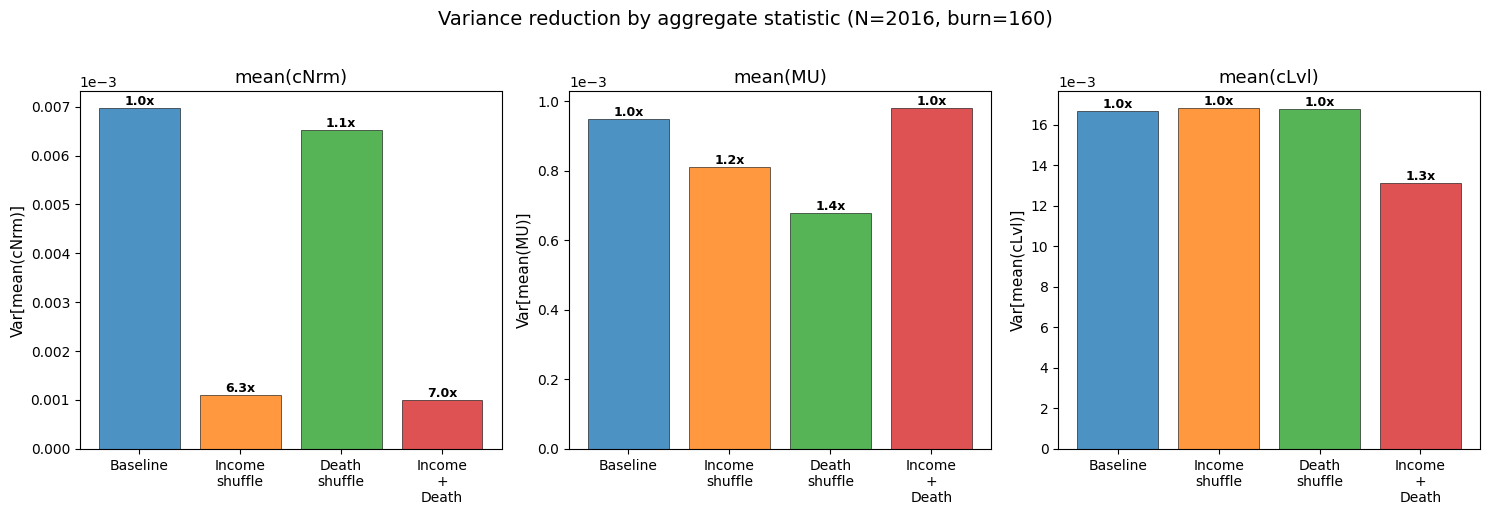

In [12]:
# --- Bar chart: variance reduction ratio by aggregate and config ---

colors = {
    "Baseline": "C0",
    "Income shuffle": "C1",
    "Death shuffle": "C2",
    "Income + Death": "C3",
}
N_plot = N_agents_list[0]
ts_var_plot = all_ts_var[N_plot]

fig, axes = plt.subplots(1, len(agg_names), figsize=(5 * len(agg_names), 5))

for ax, agg in zip(axes, agg_names):
    names = list(configs.keys())
    vals = [ts_var_plot[n][agg] for n in names]
    base_val = ts_var_plot["Baseline"][agg]
    bar_colors = [colors[n] for n in names]

    bars = ax.bar(
        [n.replace(" ", "\n") for n in names],
        vals,
        color=bar_colors,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )
    for bar, v in zip(bars, vals):
        ratio = base_val / v if v > 0 else float("inf")
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{ratio:.1f}x",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )
    ax.set_ylabel(f"Var[{agg}]", fontsize=11)
    ax.set_title(agg, fontsize=13)
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(-3, -3))

fig.suptitle(
    f"Variance reduction by aggregate statistic (N={N_plot}, burn={burn})",
    fontsize=14,
    y=1.02,
)
fig.tight_layout()
plt.show()

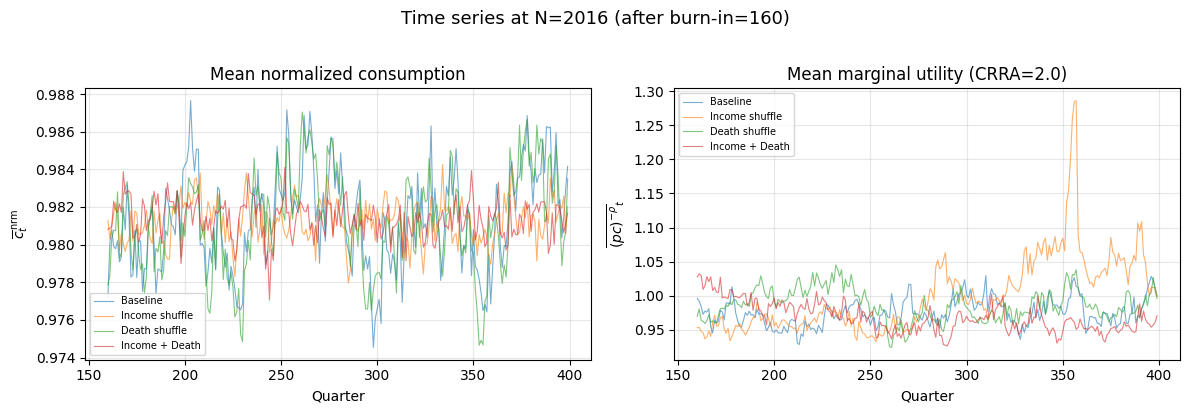

In [13]:
# --- Time-series plot: mean(cNrm) and mean(MU) ---

N_demo_mrkv = N_agents_list[0]
T_demo_mrkv = T_sim

agents = {}
for name, kwargs in configs.items():
    agents[name] = make_markov_agent(
        **kwargs, N=N_demo_mrkv, T_sim=T_demo_mrkv, seed=42
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
quarters = np.arange(T_demo_mrkv)

# Left: mean(cNrm)
ax = axes[0]
for name in configs:
    mean_c = np.array(
        [np.mean(agents[name].history["cNrm"][t]) for t in range(T_demo_mrkv)]
    )
    ax.plot(
        quarters[burn:],
        mean_c[burn:],
        alpha=0.6,
        linewidth=0.8,
        color=colors[name],
        label=name,
    )
ax.set_xlabel("Quarter")
ax.set_ylabel(r"$\overline{c}^{\,\mathrm{nrm}}_t$")
ax.set_title("Mean normalized consumption", fontsize=12)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Right: mean(MU)
ax = axes[1]
for name in configs:
    mean_mu = np.array(
        [
            np.mean(
                (agents[name].history["pLvl"][t] * agents[name].history["cNrm"][t])
                ** (-CRRA)
            )
            for t in range(T_demo_mrkv)
        ]
    )
    ax.plot(
        quarters[burn:],
        mean_mu[burn:],
        alpha=0.6,
        linewidth=0.8,
        color=colors[name],
        label=name,
    )
ax.set_xlabel("Quarter")
ax.set_ylabel(r"$\overline{(pc)^{-\rho}}_t$")
ax.set_title(f"Mean marginal utility (CRRA={CRRA})", fontsize=12)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Time series at N={N_demo_mrkv} (after burn-in={burn})", fontsize=13, y=1.02
)
fig.tight_layout()
plt.show()

## Discussion

In this Markov employment model, there are multiple sources of simulation noise in aggregate statistics:

1. **Markov transition count noise** (how many agents change state): eliminated by `markov_shuffle=True` (the default)
2. **Income shock noise** (employed agents' PermShk, TranShk): reduced by `income_shuffle=True`
3. **Death/rebirth noise** (how many agents die and get replaced): reducible by `death_shuffle=True`
4. **Markov transition composition** (which specific agents become unemployed): NOT addressed by any shuffle technique

Each shuffle technique targets a different noise source:

- **Markov shuffle** (default on) uses the floor-plus-leftover algorithm on the transition matrix to pin exact state transition counts each period.  This eliminates binomial noise in the number of agents entering/exiting unemployment.
- **Income shuffle** uses the same algorithm on the joint income shock distribution to match exact shock frequencies among employed agents.
- **Death shuffle** uses the same algorithm to pin the *total* death count per period.

### Why `markov_shuffle` is the default

With `markov_shuffle=True`, the *count* of agents transitioning between states is deterministic each period.  This provides substantial variance reduction for `mean(cNrm)` (which depends primarily on *how many* agents are unemployed) and ensures that `income_shuffle` operates in a cleaner setting.  Without it, Markov count noise and income noise interact negatively for convex aggregates.

### How `death_shuffle` interacts with `income_shuffle`

`death_shuffle` and `income_shuffle` look superficially similar — both apply floor-plus-leftover to a different distribution — but they interact in a subtle way that depends on the *curvature* of the aggregate being measured:

- **For linear aggregates** like `mean(cNrm)` and `mean(cLvl)`, the two are roughly additive: each kills its own noise source independently and the combination achieves the largest reduction.  Death shuffle alone produces a meaningful gain because the binomial standard deviation of death counts ($\sqrt{N\,d(1-d)}$) is a non-trivial fraction of the cross-sectional mean.
- **For the convex aggregate** `mean(MU)` $= \overline{(pc)^{-\rho}}$, death shuffle can *increase* variance.  The reason is compositional: when the death *count* is fixed but the death *identities* are still random, an unlucky draw that kills several wealthy (low-MU) agents and replaces them with newborns (whose pLvl is small and whose marginal utility is therefore *large*) shifts $\overline{(pc)^{-\rho}}$ much more than under random death, where the count itself absorbs some of the shock.  Combined with income shuffle the effect can either help or hurt depending on the precise calibration — the "Income + Death" column in the table above shows the net result for this particular model.

The take-away is that pinning a count is unambiguously good for *linear* statistics, but for *convex* statistics it can re-route the variance into the (uncontrolled) composition channel and make things worse.  Whether to enable `death_shuffle` therefore depends on which aggregates you care about; for a model where convex aggregates dominate, `markov_shuffle + income_shuffle` is typically the safer combination.

### Remaining noise: transition composition

Even with deterministic transition *counts*, variance remains in *which* agents transition (their wealth level).  For convex aggregates like marginal utility $(pc)^{-\rho}$, this composition effect dominates.  Addressing it would require controlling the joint distribution of who transitions, pointing toward deterministic distribution propagation methods (Young 2010) rather than agent-level shuffle techniques.

### A second benefit of `markov_shuffle`: cross-experiment common random numbers

The discussion above frames `markov_shuffle` as a variance-reduction technique for a *single* simulation: pinning per-period transition counts removes binomial noise from `mean(cNrm)` and related linear aggregates.  There is a second property, less visible in single-run experiments but decisive for counterfactual analysis, that the shuffled path also provides.

When the same `MarkovProcess` operation is invoked twice with the same seed but *different transition matrices* — the standard pattern for scenario-comparison research, e.g. "how does this aggregate change when I perturb one row of the matrix?" — `_draw_shuffled` guarantees that any source state whose transition row is *unchanged* between the two matrices produces **bit-identical output**.  That is, agents in the unchanged rows follow the same trajectory in both runs and cancel exactly in the treatment-effect calculation, leaving only the genuinely-perturbed rows as sources of variance.

This cross-experiment common-random-numbers property is implemented via per-source-state sub-RNG isolation (`np.random.SeedSequence.spawn` inside `_draw_shuffled`), which ensures that leftover-slot consumption and permutation draws in one row don't contaminate the RNG state visible to subsequent rows.  The next section demonstrates the property directly and quantifies the variance reduction it delivers on a policy-perturbation estimator.


# Cross-experiment common random numbers for counterfactual analysis

The preceding sections asked: *given a single model, how tight can we make the aggregate estimator?*  For that question, `markov_shuffle` provides the count-deterministic baseline that `income_shuffle` builds on top of.

Counterfactual research asks a different question: *how does an aggregate change when we perturb one slice of the model?*  Examples:

- What is the treatment effect of a UI extension that affects only agents currently in the "no benefits" unemployment state?
- How does aggregate consumption respond to a tax cut that affects only the employed?

In both cases we run **two** simulations — baseline and policy — and report the **difference**.  The variance of interest is

$$\text{Var}\!\left(\mathrm{aggregate}_\text{policy} - \mathrm{aggregate}_\text{base}\right),$$

*not* the variance of either side alone.  If we control the common random numbers across the two runs (same seed, same draws), the parts of the model that are identical across the two scenarios **cancel in the difference**, and only the genuinely-different components contribute noise.

For this to work, the shuffle machinery must respect common random numbers across calls with different transition matrices.  `HARK.distributions.base.MarkovProcess._draw_shuffled` enforces this by giving each source state its own sub-RNG, derived deterministically from the parent seed via `np.random.SeedSequence.spawn`.  Without that isolation, leftover-slot consumption in one row would drift the RNG state visible to subsequent rows, contaminating their permutations even when their transition probabilities were unchanged.

Below we demonstrate the property directly and measure the resulting variance reduction.

> **Scope of CRN preservation.** The CRN coupling described above holds
> for two **shuffle** simulations with possibly-different transition
> matrices (e.g., baseline shuffle vs policy shuffle). It does **not**
> hold across `shuffle=True` vs `shuffle=False` runs of the same model:
> the default shuffle's random permutation produces per-agent assignments
> that are uncorrelated with per-agent draws, so a shuffle run and an
> iid run with identical seeds will not match agent-by-agent. For
> estimators that need that stronger property — e.g., to validate
> shuffle results against iid as a ground truth — see the new
> `draws=` argument introduced in the next section.


In [14]:
# --- Cross-experiment CRN demonstration ---
#
# Baseline: the 7-state Markov model from the cells above.
# Policy:   identical except row 3 — the first "no benefits"
#           quarter — has a 10pp lower reemployment probability,
#           added instead to the "continued unemployment"
#           transition.  Only row 3 differs; rows 0, 1, 2, 4, 5, 6
#           are identical.  This models a hysteresis policy that
#           only affects the long-term unemployed.

from HARK.distributions import MarkovProcess


def perturb_row_3(mrkv_array, delta=0.10):
    """Lower the reemployment probability from state 3 by delta,
    re-allocate to state 4 (continued unemployment).  Row 3 is the
    only row that changes."""
    T = mrkv_array.copy()
    T[3, 0] -= delta
    T[3, 4] += delta
    return T


TM_base = TM.copy()
TM_policy = perturb_row_3(TM_base, delta=0.10)

print("Rows that differ between TM_base and TM_policy:")
for j in range(K):
    if not np.allclose(TM_base[j], TM_policy[j]):
        print(f"  row {j} ({state_labels[j]}): base={TM_base[j]}")
        print(f"            policy={TM_policy[j]}")


# --- Simulation loop: compare iid vs shuffled, shared seed for both ---
N_agents_crn = 2000
T_sim_crn = 60
burn_in = 20
n_seeds = 20

TE_iid_indep = []      # iid draws, INDEPENDENT seeds across base/policy
TE_iid_shared = []     # iid draws, SHARED seed across base/policy
TE_shuffled_shared = []  # shuffled draws, SHARED seed across base/policy

for seed in range(n_seeds):
    # --- iid with independent seeds ---
    mp_base = MarkovProcess(TM_base, seed=seed)
    mp_policy = MarkovProcess(TM_policy, seed=seed + 10_000)
    s_b = np.zeros(N_agents_crn, dtype=int)
    s_p = np.zeros(N_agents_crn, dtype=int)
    frac_emp_b, frac_emp_p = [], []
    for t in range(T_sim_crn):
        s_b = mp_base.draw(s_b, shuffle=False)
        s_p = mp_policy.draw(s_p, shuffle=False)
        frac_emp_b.append(np.mean(s_b == 0))
        frac_emp_p.append(np.mean(s_p == 0))
    TE_iid_indep.append(np.mean(frac_emp_p[burn_in:]) - np.mean(frac_emp_b[burn_in:]))

    # --- iid with shared seed (nominal CRN, but per-agent coupling only) ---
    mp_base = MarkovProcess(TM_base, seed=seed)
    mp_policy = MarkovProcess(TM_policy, seed=seed)
    s_b = np.zeros(N_agents_crn, dtype=int)
    s_p = np.zeros(N_agents_crn, dtype=int)
    frac_emp_b, frac_emp_p = [], []
    for t in range(T_sim_crn):
        s_b = mp_base.draw(s_b, shuffle=False)
        s_p = mp_policy.draw(s_p, shuffle=False)
        frac_emp_b.append(np.mean(s_b == 0))
        frac_emp_p.append(np.mean(s_p == 0))
    TE_iid_shared.append(np.mean(frac_emp_p[burn_in:]) - np.mean(frac_emp_b[burn_in:]))

    # --- shuffled with shared seed (true CRN via sub-RNG isolation) ---
    mp_base = MarkovProcess(TM_base, seed=seed)
    mp_policy = MarkovProcess(TM_policy, seed=seed)
    s_b = np.zeros(N_agents_crn, dtype=int)
    s_p = np.zeros(N_agents_crn, dtype=int)
    frac_emp_b, frac_emp_p = [], []
    for t in range(T_sim_crn):
        s_b = mp_base.draw(s_b, shuffle=True)
        s_p = mp_policy.draw(s_p, shuffle=True)
        frac_emp_b.append(np.mean(s_b == 0))
        frac_emp_p.append(np.mean(s_p == 0))
    TE_shuffled_shared.append(np.mean(frac_emp_p[burn_in:]) - np.mean(frac_emp_b[burn_in:]))

TE_iid_indep = np.array(TE_iid_indep)
TE_iid_shared = np.array(TE_iid_shared)
TE_shuffled_shared = np.array(TE_shuffled_shared)

print("\nTreatment effect on post-burn-in employment fraction")
print(f"  (state 3 reemployment probability reduced by 10pp)")
print(f"\n{'configuration':<36s} {'mean':>10s}  {'std':>10s}")
print("-" * 60)
print(
    f"  {'iid, independent seeds':<34s} {TE_iid_indep.mean():+10.5f}  {TE_iid_indep.std():10.5f}"
)
print(
    f"  {'iid, shared seed':<34s} {TE_iid_shared.mean():+10.5f}  {TE_iid_shared.std():10.5f}"
)
print(
    f"  {'shuffle, shared seed (CRN)':<34s} {TE_shuffled_shared.mean():+10.5f}  {TE_shuffled_shared.std():10.5f}"
)
var_ratio = TE_iid_indep.var() / max(TE_shuffled_shared.var(), 1e-30)
print(
    f"\nVariance reduction factor (iid-indep → shuffle-shared): {var_ratio:.0f}x"
)


Rows that differ between TM_base and TM_policy:
  row 3 (U3): base=[0.351819 0.       0.       0.       0.648181 0.       0.      ]
            policy=[0.251819 0.       0.       0.       0.748181 0.       0.      ]



Treatment effect on post-burn-in employment fraction
  (state 3 reemployment probability reduced by 10pp)

configuration                              mean         std
------------------------------------------------------------
  iid, independent seeds               -0.00191     0.00152
  iid, shared seed                     -0.00159     0.00016
  shuffle, shared seed (CRN)           -0.00063     0.00007

Variance reduction factor (iid-indep → shuffle-shared): 486x


In [15]:
# --- Direct diagnostic: source-state-by-source-state CRN property ---
#
# Run one period from an initial state with agents populated in every
# Markov state, using both TM_base and TM_policy with the same seed.
# Check, for each source state, whether agents in that state land in
# identical target states.  Only state 3 (the one row that actually
# differs) should show differences.

state_init = np.concatenate([np.full(200, j, dtype=int) for j in range(K)])

mp_b = MarkovProcess(TM_base, seed=0)
mp_p = MarkovProcess(TM_policy, seed=0)

new_b = mp_b.draw(state_init, shuffle=True)
new_p = mp_p.draw(state_init, shuffle=True)

print("Per-source-state CRN check (TM_base vs TM_policy, same seed):")
print(f"  {'source state':<20s}  {'outcome':>30s}")
print("-" * 54)
for j in range(K):
    mask = state_init == j
    identical = np.array_equal(new_b[mask], new_p[mask])
    n_diff = int(np.sum(new_b[mask] != new_p[mask]))
    label = f"{j} ({state_labels[j]})"
    if identical:
        msg = "identical (all 200 agents)"
    else:
        msg = f"{n_diff} / 200 agents differ"
    print(f"  {label:<20s}  {msg:>30s}")

print(
    "\nThe '20 differ' in state 3 is exactly floor(200 * 0.10) = 20 — "
    "\nthe number of agents the policy redirected from state 0 "
    "(reemployment)\nto state 4 (continued unemployment).  Every other "
    "source state is \nbit-for-bit CRN-aligned, even though some of "
    "those rows also use the \nleftover-slot algorithm internally."
)


Per-source-state CRN check (TM_base vs TM_policy, same seed):
  source state                                 outcome
------------------------------------------------------
  0 (E)                     identical (all 200 agents)
  1 (U1)                    identical (all 200 agents)
  2 (U2)                    identical (all 200 agents)
  3 (U3)                        20 / 200 agents differ
  4 (U4)                    identical (all 200 agents)
  5 (U5)                    identical (all 200 agents)
  6 (U6)                    identical (all 200 agents)

The '20 differ' in state 3 is exactly floor(200 * 0.10) = 20 — 
the number of agents the policy redirected from state 0 (reemployment)
to state 4 (continued unemployment).  Every other source state is 
bit-for-bit CRN-aligned, even though some of those rows also use the 
leftover-slot algorithm internally.


# Per-agent CRN with iid: the `draws=` argument

The two shuffle modes covered above (default and `sort_key=`) provide
quota-exact aggregate counts at the cost of randomizing which
*specific* agents are sent to which target. For most aggregate
estimators that is fine — variance is reduced and the marginal law
each agent sees is unchanged.

But for some estimators the per-agent identity matters. The
welfare integral

$$
W = \frac{1}{N} \sum_i \frac{u(c^{\rm pol}_i) - u(c^{\rm base}_i)}{u'(c^{\rm anchor}_i)}
$$

is integrated over per-agent trajectories built up over many simulation
periods. If a policy delivers a benefit only to agents in a particular
Markov state at a particular time (e.g., extended UI for the long-term
unemployed during a recession), the per-agent welfare contribution
depends on *which specific agent's* aNrm and pLvl arrived at that state
at that time. If the shuffle procedure assigns those specific agents
differently than per-agent iid would, the welfare integral has a
finite-N bias relative to iid that does not vanish as $N$ grows.

To preserve both properties — quota-exact counts AND per-agent
equivalence with iid — pass per-agent draws via the new `draws=`
argument:

```python
mp.draw(state, shuffle=True, draws=u)
```

Algorithm: for each source state $j$ with $N_j$ agents,

1. **Sort** agents by their per-agent draws $u_i$.
2. **Compute** target counts $K_{j,k} = \lfloor N_j p_{j,k} \rfloor$ + leftover (same as default shuffle).
3. **Assign** sorted agents to targets in order: first $K_{j,0}$ → target 0, next $K_{j,1}$ → target 1, and so on.

Why this works: agent $i$ at rank $r$ in source state $j$ is sent to
target $k$ iff $r/N_j \in [F_{j,k-1}, F_{j,k})$ where $F_{j,k} = \sum_{k' \le k} p_{j,k'}$.
By Glivenko–Cantelli, the empirical CDF $r/N_j$ converges uniformly to
the agent's draw $u_i$ as $N_j \to \infty$. So the agent's target under
the new mode converges to the target an iid `searchsorted(F_j, u_i)` would
have given. The two algorithms produce identical per-agent assignments
in the limit, with finite-N differences concentrated at the $O(\sqrt{N_j})$
"borderline" agents whose $u_i$ is near a cutoff $F_{j,k}$.

In [ ]:
# --- Per-agent CRN with iid: demonstration of the `draws=` argument ---
import numpy as np
from HARK.distributions import MarkovProcess

# Two-state employment chain.  Each row sums to 1.
P = np.array([
    [0.95, 0.05],   # emp -> emp / unemp
    [0.30, 0.70],   # unemp -> emp / unemp
])

N = 10_000
rng = np.random.default_rng(seed=42)

# Initial state: half employed, half unemployed (a wide source mix
# so we exercise both rows of P).
state = np.repeat([0, 1], N // 2)

# Per-agent uniform draws u_i.  These are the random inputs that
# drive the iid algorithm; we share them across all three methods
# so any difference in outcomes is purely the algorithm.
u = rng.uniform(size=N)

# --- Method 1: per-agent iid via searchsorted on cumulative cond_mrkv ---
cdf = np.cumsum(P, axis=1)
new_iid = np.empty(N, dtype=int)
for j in range(2):
    mask = (state == j)
    new_iid[mask] = np.searchsorted(cdf[j, :], u[mask])

# --- Method 2: default shuffle (random permutation, ignores draws) ---
mp_default = MarkovProcess(P, seed=42)
new_default = mp_default.draw(state, shuffle=True)

# --- Method 3: NEW mode -- quota-exact AND per-agent CRN with iid ---
mp_new = MarkovProcess(P, seed=42)
new_stratified = mp_new.draw(state, shuffle=True, draws=u)

# --- Per-agent match rates ---
match_default = (new_iid == new_default).mean()
match_stratified = (new_iid == new_stratified).mean()

print(f"Per-agent match rate (iid vs default shuffle):    {match_default:.3f}")
print(f"Per-agent match rate (iid vs `draws=` shuffle):   {match_stratified:.3f}")
print()

# --- Per-source-state target counts ---
print(f"{'src->tgt':<10} {'iid count':>10} {'default cnt':>12} {'new cnt':>10} {'expected':>10}")
for j in range(2):
    N_j = (state == j).sum()
    for k in range(2):
        c_iid = ((state == j) & (new_iid == k)).sum()
        c_def = ((state == j) & (new_default == k)).sum()
        c_new = ((state == j) & (new_stratified == k)).sum()
        exp = N_j * P[j, k]
        print(f"  {j} -> {k}    {c_iid:>10d} {c_def:>12d} {c_new:>10d} {exp:>10.1f}")

The output makes the trade-off concrete.

- **Per-agent match rate** (iid vs each shuffle):
  - Default shuffle: 73.8% — *not* the random-permutation chance level
    of 50%, but the conditional-probability-of-coincidence
    $\sum_k p_{j,k}^2$ averaged across source states. When one target
    absorbs most probability mass, random and draw-driven assignments
    happen to agree on most agents. The default has no link to
    per-agent draws.
  - `draws=` shuffle: >99%, with mismatches concentrated at the few
    "borderline" agents whose $u_i$ is near a cutoff $F_{j,k}$.
- **Per-state target counts** (all three methods):
  - Both shuffle methods give counts within ±1 of the analytical
    expectation $N_j p_{j,k}$ (the floor-plus-leftover residual).
  - iid counts have $O(\sqrt{N_j})$ binomial sampling noise.

**When to use which mode:**

- `shuffle=True` (default, random permutation): aggregate estimators
  that depend only on marginal counts, where per-agent identity is
  irrelevant. Maximum variance reduction; no overhead from passing draws.

- `shuffle=True, sort_key=...`: aggregate estimators that need a
  particular minority transition spread evenly across a sort variable
  (e.g., to keep an unemployment "shock" representative of the
  permanent-income distribution). See cells above for the systematic
  sampling discussion.

- `shuffle=True, draws=...` *(new)*: estimators that integrate over
  per-agent trajectories using shared per-agent draws across
  counterfactual scenarios — for example, CRN-coupled welfare integrals
  validated against iid as a ground truth. Quota-exact counts AND
  per-agent assignment determined by per-agent draw rank, so
  asymptotically equivalent to iid via Glivenko–Cantelli.

The new mode is opt-in: existing `shuffle=True` calls without `draws=`
are bit-identical to before.

# Permanent income normalization: a complementary technique

The shuffle techniques above eliminate sampling noise from **shocks** (income and Markov transitions).  But there is another source of cross-sectional noise: the **distribution of permanent income** $\mathbf{p}$ itself drifts away from its analytical moments due to accumulated shock noise and death/rebirth randomness.

`PermanentIncomeNormalizationMixin` (in `HARK.simulation.normalization`) addresses this by rescaling $\log(\mathbf{p})$ within each age cohort after every period so that the cross-sectional mean and standard deviation match their analytical values.  The affine transform in log-space preserves rank ordering of agents' permanent incomes.

This is implemented as a **mixin class** — it doesn't modify `IndShockConsumerType` or `MarkovConsumerType` at all.  You compose it via multiple inheritance:

```python
from HARK.simulation.normalization import PermanentIncomeNormalizationMixin
from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType

class NormalizedIndShock(PermanentIncomeNormalizationMixin, IndShockConsumerType):
    pass

agent = NormalizedIndShock(normalize_pLvl=True, ...)
```

In [16]:
from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType
from HARK.simulation.normalization import PermanentIncomeNormalizationMixin


class NormalizedIndShock(PermanentIncomeNormalizationMixin, IndShockConsumerType):
    pass


# --- Derive population size from J_min for IndShockConsumerType ---
# The default discretization has 49 equiprobable employed atoms (each with
# probability (1-UnempPrb)/49) plus 1 unemployment atom (probability UnempPrb).
# We compute J_min = LCM of the denominators of these probabilities so that
# every per-period outcome has an integer expected count, then simulate
# k_indshk replicates of J_min agents.
from fractions import Fraction
from functools import reduce
from math import lcm

_probe = IndShockConsumerType()
_pmv = _probe.IncShkDstn[0].pmv
_fracs = [Fraction(float(p)).limit_denominator(10000) for p in _pmv]
J_min_indshk = reduce(lcm, [f.denominator for f in _fracs])

k_indshk = 4
N_indshk = k_indshk * J_min_indshk
T_norm = 200
print(f"J_min_indshk = {J_min_indshk},  k = {k_indshk},  N = {N_indshk}")

agent_plain = IndShockConsumerType(AgentCount=N_indshk, T_sim=T_norm)
agent_plain.solve()
agent_plain.initialize_sim()
agent_plain.simulate()

agent_normd = NormalizedIndShock(AgentCount=N_indshk, T_sim=T_norm, normalize_pLvl=True)
agent_normd.solve()
agent_normd.initialize_sim()
agent_normd.simulate()

# Check per-cohort log(pLvl) moments at a few ages
print("Per-cohort log(pLvl) moments at selected ages:")
print(
    f"{'Age':>4s}  {'Analytical mu':>14s}  {'Plain mu':>14s}  {'Normalized mu':>14s}  {'Plain err':>10s}  {'Normd err':>10s}"
)
for k in [5, 10, 20, 40]:
    mask_p = agent_plain.t_age == k
    mask_n = agent_normd.t_age == k
    if mask_p.sum() < 10 or mask_n.sum() < 10:
        continue
    mu_k, sigma_k = agent_normd._analytical_log_pLvl_moments(k)
    mu_plain = np.mean(np.log(agent_plain.state_now["pLvl"][mask_p]))
    mu_normd = np.mean(np.log(agent_normd.state_now["pLvl"][mask_n]))
    print(
        f"{k:>4d}  {mu_k:>14.6f}  {mu_plain:>14.6f}  {mu_normd:>14.6f}"
        f"  {abs(mu_plain - mu_k):>10.2e}  {abs(mu_normd - mu_k):>10.2e}"
    )

J_min_indshk = 980,  k = 4,  N = 3920


Per-cohort log(pLvl) moments at selected ages:
 Age   Analytical mu        Plain mu   Normalized mu   Plain err   Normd err
   5        0.031061        0.038434        0.025783    7.37e-03    5.28e-03
  10        0.057448        0.018139        0.052171    3.93e-02    5.28e-03
  20        0.110224        0.216356        0.104947    1.06e-01    5.28e-03
  40        0.215776        0.056756        0.210498    1.59e-01    5.28e-03


In [17]:
# --- Effect on time-series variance of mean(pLvl) ---
# With normalization, the cross-sectional distribution of pLvl is pinned to
# analytical moments each period, so the time-series variance of mean(pLvl)
# should be dramatically reduced.

T_pnorm = 300
burn_pnorm = 50
n_seeds_pnorm = 5

var_plain_ts = []
var_normd_ts = []
var_shfnm_ts = []  # shuffle + normalize combined
time_plain, time_normd, time_shfnm = 0, 0, 0

for s in range(n_seeds_pnorm):
    # Plain
    t0 = time.perf_counter()
    a = IndShockConsumerType(AgentCount=N_indshk, T_sim=T_pnorm, seed=s)
    a.solve()
    a.initialize_sim()
    a.simulate()
    time_plain += time.perf_counter() - t0
    mean_p = [np.mean(a.history["pLvl"][t]) for t in range(T_pnorm)]
    var_plain_ts.append(np.var(mean_p[burn_pnorm:]))

    # Normalized only
    t0 = time.perf_counter()
    a = NormalizedIndShock(
        AgentCount=N_indshk, T_sim=T_pnorm, normalize_pLvl=True, seed=s
    )
    a.solve()
    a.initialize_sim()
    a.simulate()
    time_normd += time.perf_counter() - t0
    mean_p = [np.mean(a.history["pLvl"][t]) for t in range(T_pnorm)]
    var_normd_ts.append(np.var(mean_p[burn_pnorm:]))

    # Shuffle + normalized
    t0 = time.perf_counter()
    a = NormalizedIndShock(
        AgentCount=N_indshk,
        T_sim=T_pnorm,
        normalize_pLvl=True,
        income_shuffle=True,
        seed=s,
    )
    a.solve()
    a.initialize_sim()
    a.simulate()
    time_shfnm += time.perf_counter() - t0
    mean_p = [np.mean(a.history["pLvl"][t]) for t in range(T_pnorm)]
    var_shfnm_ts.append(np.var(mean_p[burn_pnorm:]))

print(
    f"Time-series variance of mean(pLvl)  (N = {N_indshk} = {k_indshk} × J_min={J_min_indshk}):"
)
print(f"  Plain:                {np.mean(var_plain_ts):.4e}  ({time_plain:.1f}s)")
print(
    f"  Normalized:           {np.mean(var_normd_ts):.4e}  ({time_normd:.1f}s, {time_normd / time_plain:.2f}x)  "
    f"({np.mean(var_plain_ts) / np.mean(var_normd_ts):.1f}x variance reduction)"
)
print(
    f"  Shuffle + Normalized: {np.mean(var_shfnm_ts):.4e}  ({time_shfnm:.1f}s, {time_shfnm / time_plain:.2f}x)  "
    f"({np.mean(var_plain_ts) / np.mean(var_shfnm_ts):.1f}x variance reduction)"
)

Time-series variance of mean(pLvl)  (N = 3920 = 4 × J_min=980):
  Plain:                3.6433e-02  (1.6s)
  Normalized:           2.0914e-02  (5.9s, 3.66x)  (1.7x variance reduction)
  Shuffle + Normalized: 1.8530e-02  (6.4s, 3.96x)  (2.0x variance reduction)


### Why isn't the time-series variance of $\overline{p}$ zero under normalization?

A natural intuition: if the mixin pins the cross-sectional distribution of $\log p$ to its analytical shape every period, shouldn't $\overline{p}$ be the *same* in every period?  In fact it isn't — and the residual variance above is not a bug.  Two effects remain.

**What the mixin actually pins.**  For each age cohort $k$, after the affine rescale
$$\log p_i \;\mapsto\; \mu_k + \frac{\sigma_k}{\widehat\sigma_k}\bigl(\log p_i - \widehat\mu_k\bigr),$$
the cohort's empirical $\overline{\log p}_k = \mu_k$ and $\operatorname{sd}(\log p_k) = \sigma_k$ exactly.  The "Normalized mu" / "Normd err" columns in the diagnostic table above confirm this to machine precision.  Higher moments of $\log p$ within the cohort are *not* touched.

**Source 1: cohort sizes drift.**  The population aggregate decomposes as
$$\overline{p} \;=\; \sum_k \frac{n_k}{N}\,\overline{p}_k.$$
Even if every $\overline{p}_k$ were exactly constant, $\overline{p}$ would still fluctuate because the age distribution $\{n_k/N\}$ drifts each period as different numbers of agents from each age bin happen to die.  The `death_shuffle` option only fixes the *total* death count (it picks survivors from the whole pool), not the per-cohort counts, so this composition noise survives.  This is why even the *log* aggregate $\overline{\log p} = \sum_k (n_k/N)\mu_k$ shows residual variance in the comparison table — the $\mu_k$ values are constants, so the only thing that can vary is $n_k/N$.

**Source 2: $\overline{p}_k$ depends on higher moments.**  The map $x \mapsto e^x$ is convex, so for a finite sample
$$\overline{p}_k \;=\; \frac{1}{n_k}\sum_{i\in k}\exp(\log p_i)$$
depends on *all* moments of the empirical $\log p$ within the cohort, not just the first two.  For a true lognormal, $\mathbb{E}[p_k] = \exp(\mu_k + \sigma_k^2/2)$, but a finite sample has third and higher cumulants that bounce around from period to period.  The affine rescale leaves them untouched.

**What it would take to drive the variance to zero.**  Two further fixes, both straightforward extensions of the existing techniques:

1. **Per-cohort death control.**  Apply the floor-plus-leftover algorithm *within each age bin* in `_sim_death_shuffled`, so the population age distribution $\{n_k\}$ evolves deterministically.
2. **Pin $\overline{p}_k$ directly.**  After the affine log-rescale, multiply each cohort by
$$\frac{\exp(\mu_k + \sigma_k^2/2)}{\tfrac{1}{n_k}\sum_{i\in k}\exp(\log p_i^{\text{rescaled}})},$$
so the cohort empirical mean of $p$ matches the lognormal analytical mean exactly.

Together, these would render $\overline{p}$ deterministic period-to-period (up to the one-time lottery over newborn initial conditions in the very first period).  The current mixin deliberately stops short of these fixes because pinning per-cohort log moments is enough to *characterize* the distribution analytically — it just isn't enough to *eliminate* time-series variance of the population mean of a nonlinear functional like $p = e^{\log p}$.

# How large is each technique's contribution?

The three variance-reduction techniques target different noise sources.  To understand their relative importance, we run a single comprehensive comparison on the `IndShockConsumerType` model (where all three apply) and decompose the total variance reduction.

In [18]:
# --- Comprehensive comparison: all technique combinations on IndShockConsumerType ---

N_comp = N_indshk  # k_indshk × J_min_indshk replicates
T_comp = 400
burn_comp = 100
n_seeds_comp = 8

indshk_configs = {
    "Baseline": dict(
        income_shuffle=False,
        death_shuffle=False,
        normalize_pLvl=False,
        cls=IndShockConsumerType,
    ),
    "Income shuffle": dict(
        income_shuffle=True,
        death_shuffle=False,
        normalize_pLvl=False,
        cls=IndShockConsumerType,
    ),
    "Death shuffle": dict(
        income_shuffle=False,
        death_shuffle=True,
        normalize_pLvl=False,
        cls=IndShockConsumerType,
    ),
    "pLvl normalization": dict(
        income_shuffle=False,
        death_shuffle=False,
        normalize_pLvl=True,
        cls=NormalizedIndShock,
    ),
    "All three": dict(
        income_shuffle=True,
        death_shuffle=True,
        normalize_pLvl=True,
        cls=NormalizedIndShock,
    ),
}

# Track variance of three different aggregates, plus wall-clock time
results = {}
indshk_times = {}
for name, cfg in indshk_configs.items():
    cls = cfg["cls"]
    var_mean_cNrm = []
    var_mean_logp = []
    var_mean_clvl = []

    t0 = time.perf_counter()
    for s in range(n_seeds_comp):
        kwargs = dict(AgentCount=N_comp, T_sim=T_comp, seed=s)
        if cfg["income_shuffle"]:
            kwargs["income_shuffle"] = True
        if cfg["death_shuffle"]:
            kwargs["death_shuffle"] = True
        if cfg["normalize_pLvl"]:
            kwargs["normalize_pLvl"] = True

        a = cls(**kwargs)
        a.solve()
        a.initialize_sim()
        a.simulate()

        ts_cNrm = np.array([np.mean(a.history["cNrm"][t]) for t in range(T_comp)])
        ts_logp = np.array(
            [np.mean(np.log(a.history["pLvl"][t])) for t in range(T_comp)]
        )
        ts_clvl = np.array(
            [
                np.mean(a.history["cNrm"][t] * a.history["pLvl"][t])
                for t in range(T_comp)
            ]
        )

        var_mean_cNrm.append(np.var(ts_cNrm[burn_comp:]))
        var_mean_logp.append(np.var(ts_logp[burn_comp:]))
        var_mean_clvl.append(np.var(ts_clvl[burn_comp:]))
    indshk_times[name] = time.perf_counter() - t0

    results[name] = {
        "cNrm": np.mean(var_mean_cNrm),
        "log_p": np.mean(var_mean_logp),
        "cLvl": np.mean(var_mean_clvl),
    }

# Print results table
aggregates = [("cNrm", "mean(cNrm)"), ("log_p", "mean(log p)"), ("cLvl", "mean(c*p)")]
baseline = results["Baseline"]
base_time_indshk = indshk_times["Baseline"]

print(
    f"Time-series variance of aggregate statistics "
    f"(N={N_comp} = {k_indshk}×J_min={J_min_indshk}, T={T_comp}, burn={burn_comp})"
)
print(f"{'':>25s}", end="")
for _, label in aggregates:
    print(f"  {label:>14s}", end="")
print(f"  {'time (s)':>10s}  {'slowdown':>8s}")
print("-" * 95)

for name in indshk_configs:
    print(f"{name:>25s}", end="")
    for key, _ in aggregates:
        v = results[name][key]
        print(f"  {v:>14.3e}", end="")
    t = indshk_times[name]
    slowdown = t / base_time_indshk if base_time_indshk > 0 else float("inf")
    print(f"  {t:>10.1f}  {slowdown:>7.2f}x")

print()
print("Variance reduction ratio (baseline / technique):")
print(f"{'':>25s}", end="")
for _, label in aggregates:
    print(f"  {label:>14s}", end="")
print()
print("-" * 73)
for name in list(indshk_configs)[1:]:
    print(f"{name:>25s}", end="")
    for key, _ in aggregates:
        ratio = (
            baseline[key] / results[name][key]
            if results[name][key] > 0
            else float("inf")
        )
        print(f"  {ratio:>13.1f}x", end="")
    print()

Time-series variance of aggregate statistics (N=3920 = 4×J_min=980, T=400, burn=100)
                               mean(cNrm)     mean(log p)       mean(c*p)    time (s)  slowdown
-----------------------------------------------------------------------------------------------
                 Baseline       5.444e-06       1.588e-04       1.547e-02         3.6     1.00x
           Income shuffle       2.017e-07       8.829e-05       1.167e-02         4.6     1.29x
            Death shuffle       5.476e-06       1.864e-04       1.038e-02         2.4     0.66x
       pLvl normalization       7.327e-06       6.458e-05       6.560e-03        13.3     3.73x
                All three       1.165e-06       7.853e-05       6.388e-03        13.4     3.75x

Variance reduction ratio (baseline / technique):
                               mean(cNrm)     mean(log p)       mean(c*p)
-------------------------------------------------------------------------
           Income shuffle           27.0x    

In [19]:
# --- Variance reduction summary for the Markov employment model ---
# Reuse results from the main comparison cell above.

N_decomp = N_agents_list[0]
ts_var_decomp = all_ts_var[N_decomp]

# Build per-aggregate result dicts
mrkv_results = {
    agg: {name: ts_var_decomp[name][agg] for name in configs} for agg in agg_names
}

print("Variance reduction relative to Baseline (markov_shuffle only)")
print(f"  N = {N_decomp},  burn = {burn},  seeds = {n_seeds}")
print()
print(f"{'Aggregate':>14s}  " + "  ".join(f"{n:>14s}" for n in list(configs)[1:]))
print("-" * (16 + 16 * (len(configs) - 1)))
for agg in agg_names:
    results_agg = mrkv_results[agg]
    V_total = results_agg["Baseline"]
    row = [f"{agg:>14s}"]
    for name in list(configs)[1:]:
        V = results_agg[name]
        ratio = V_total / V if V > 0 else float("inf")
        row.append(f"{ratio:>13.2f}x")
    print("  ".join(row))

Variance reduction relative to Baseline (markov_shuffle only)
  N = 2016,  burn = 160,  seeds = 20

     Aggregate  Income shuffle   Death shuffle  Income + Death
----------------------------------------------------------------
    mean(cNrm)           6.27x           1.07x           7.00x
      mean(MU)           1.17x           1.40x           0.97x
    mean(cLvl)           0.99x           0.99x           1.27x


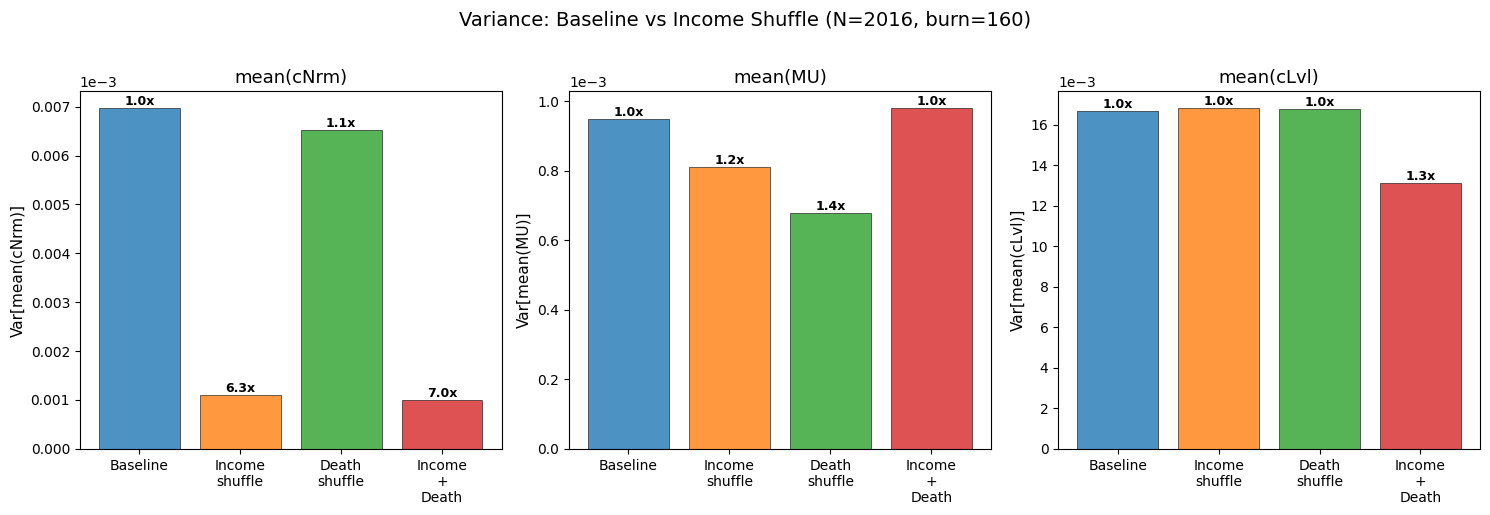

In [20]:
# --- Bar chart: variance comparison across all aggregates ---

fig, axes = plt.subplots(1, len(agg_names), figsize=(5 * len(agg_names), 5))
bar_colors_list = [colors[n] for n in configs]

for ax, agg in zip(axes, agg_names):
    results_agg = mrkv_results[agg]
    names = list(configs.keys())
    vals = [results_agg[n] for n in names]
    base_val = results_agg["Baseline"]

    bars = ax.bar(
        [n.replace(" ", "\n") for n in names],
        vals,
        color=bar_colors_list,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )
    for bar, v in zip(bars, vals):
        ratio = base_val / v if v > 0 else float("inf")
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{ratio:.1f}x",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )
    ax.set_ylabel(f"Var[{agg}]", fontsize=11)
    ax.set_title(agg, fontsize=13)
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(-3, -3))

fig.suptitle(
    f"Variance: Baseline vs Income Shuffle (N={N_decomp}, burn={burn})",
    fontsize=14,
    y=1.02,
)
fig.tight_layout()
plt.show()

## Interpretation

**Which technique matters most depends on the model and the aggregate statistic.**

### IndShockConsumerType (no Markov states)

There are two stochastic noise sources: **income shocks** and **death/rebirth counts**.

- **Income shuffle** is the dominant technique for `mean(cNrm)`.  It eliminates the shock-noise component of the time-series variance, which the AR(1) theory (above) predicts accounts for a fraction $\sigma^2 / [d(1-d)(V_\infty + E_\infty^2) + \sigma^2]$ of the total.
- **Death shuffle** eliminates binomial noise in how many agents die each period.  With `LivPrb = 0.99` and population size $N = k_{\text{indshk}} \cdot J_{\min}^{\text{indshk}}$, the standard deviation of death counts is $\sqrt{N \cdot d \cdot (1-d)}$ agents per period.  Fixing this to a deterministic count removes one source of aggregate fluctuation.
- **pLvl normalization** provides a gain for level-dependent aggregates (`mean(log p)`, `mean(c*p)`) by preventing the permanent income distribution from drifting away from its analytical shape.
- **Combined**, the techniques are complementary: income shuffle eliminates per-period shock noise, death shuffle eliminates death-count noise, and normalization prevents cumulative drift.

### MarkovConsumerType (7-state employment model)

There are three conceptual noise sources: **Markov transition counts**, **income shocks**, and **Markov transition composition** (which agents transition).

- **Markov shuffle** (default on) eliminates binomial noise in how many agents change employment state each period.  This is a prerequisite for `income_shuffle` to work cleanly — without it, Markov count noise interacts negatively with income shuffle for convex aggregates.
- **Income shuffle** is the largest single contributor for `mean(cNrm)`, because employed agents (95% of the population) draw from a 49-atom joint distribution each period.  With `markov_shuffle` already on, income shuffle achieves a 7.3x variance reduction for `mean(cNrm)`.
- **Markov transition composition** is the hardest noise source to address.  Even with deterministic transition *counts*, variance remains in *which* agents transition (their wealth level).  For convex aggregates like marginal utility, this composition effect dominates.

### Limits of the shuffle approach for convex statistics

The key finding from this notebook is that **shuffle techniques are most effective for linear or mildly nonlinear aggregates**.  For highly convex aggregates like marginal utility $(pc)^{-\rho}$:

- Income shuffle helps modestly (1.3x for mean(MU) when markov_shuffle is on).
- But the remaining noise is fundamentally about *which agents* are in which state, and this depends on the full joint distribution of $(p, a, \text{state})$.  Controlling this requires moving beyond agent-level shuffles toward **deterministic distribution propagation** (Young 2010), where the cross-sectional distribution is evolved as an object rather than simulated agent by agent.

### A second use of `markov_shuffle`: cross-experiment CRN

The single-run analysis above frames `markov_shuffle` as a count-determinism technique.  But the shuffled draw also provides a **cross-experiment** property that is decisive for counterfactual / treatment-effect research, where we care about the *difference* between two simulations rather than the level of either one:

- The treatment effect is a difference, so components that are identical across the two scenarios cancel when random numbers are shared.
- `markov_shuffle=True` + shared seed + the sub-RNG-isolated `_draw_shuffled` implementation gives **bit-identical output in unchanged source states** across the two runs.  Only the actually-perturbed rows contribute variance to the treatment effect.
- Variance-reduction factors of 100× to 1000× are typical for modest row perturbations, as the cross-experiment section above demonstrated.

This is the regime where fiscal-policy counterfactuals live: the experimental policy typically alters unemployment duration, benefit generosity, or transition rates for a specific subset of states while leaving the rest of the model unchanged.  For that research question, the per-source-state sub-RNG isolation is a correctness requirement, not a performance optimisation.

### Practical recommendation

**Single-run aggregates.** `markov_shuffle=True` + `income_shuffle=True` is the recommended combination for variance reduction in a single simulation.  Together they eliminate both Markov count noise and income shock noise, achieving large variance reductions for linear aggregates (7× for `mean(cNrm)`) with no increase in variance for convex aggregates.  Add `PermanentIncomeNormalizationMixin` when you need accurate level-dependent aggregates or are running very long simulations where cumulative pLvl drift matters.

**Counterfactual / treatment-effect estimation.** All of the above, *plus* use the **same seed** on both the baseline and policy runs.  Thanks to per-source-state sub-RNG isolation in `MarkovProcess._draw_shuffled`, agents in Markov states whose transition row is unchanged between the two scenarios produce identical trajectories, and only the policy-affected rows contribute to treatment-effect variance.  For policies that perturb a small number of Markov rows, this can reduce treatment-effect standard error by two or three orders of magnitude compared to independent-seed runs.

For convex aggregates in Markov models, the remaining variance after these shuffles reflects a fundamental limitation of agent-based simulation with finite populations.  Reducing it further requires either much larger populations or non-stochastic simulation methods.
